# Modelos de Predicción de Volatilidad Intradía — Magnificent 7

**Objetivo:** Evaluar si el sentimiento (GDELT + Reddit + FinBERT) mejora la predicción de volatilidad intradía frente a modelos basados solo en precios históricos.

**Variable objetivo:** `vol_fwd_6h` — volatilidad realizada forward-looking (próximas 6 barras horarias ≈ 1 día de trading)

**Modelos:**
1. **Naif (persistencia):** vol_fwd_6h(t) = vol_realized_6h(t)
2. **GARCH(1,1):** Solo retornos horarios históricos (baseline econométrico)
3. **GARCH-X(1,1):** GARCH + tono GDELT + sentimiento FinBERT como variables exógenas
4. **XGBoost:** Modelo ML con todas las variables (retornos, volatilidad, sentimiento, temporales)

**Periodo:** 2024-04-03 → 2026-04-02 | Barras horarias (9:30-15:30 ET, 7 barras/día)

## 0. Imports y carga de datos

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from arch import arch_model
from arch.univariate import ARX, GARCH as GARCHVol, Normal, GeneralizedError
from scipy import stats
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# --- Configuración global ---
BASE_DIR = Path('..').resolve()
FIGURAS = BASE_DIR / 'docs' / 'figuras'
FIGURAS.mkdir(parents=True, exist_ok=True)

TICKERS = ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
TRAIN_RATIO = 0.80
RANDOM_SEED = 42
FACTOR_ANUAL = np.sqrt(252 * 6.5)  # factor de anualización para datos horarios

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 10,
    'figure.dpi': 120,
})

print(f"Directorio base: {BASE_DIR}")
print(f"Factor de anualización: {FACTOR_ANUAL:.2f}")

Directorio base: /home/daniel-palacios/TFG-Magnificent7-Sentiment-Risk
Factor de anualización: 40.47


In [2]:
# --- Carga del dataset integrado intradía ---
ruta_csv = BASE_DIR / 'data' / 'clean' / 'dataset_intraday_integrado.csv'
df = pd.read_csv(ruta_csv)
df['datetime'] = pd.to_datetime(df['datetime'], utc=True).dt.tz_localize(None)
df = df.sort_values(['ticker', 'datetime']).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Periodo: {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Tickers: {sorted(df['ticker'].unique())}")
print(f"\nNulos ANTES de interpolar (columnas de sentimiento):")

# Columnas de sentimiento a interpolar
SENT_COLS = [
    'gdelt_tone_mean', 'gdelt_tone_std', 'gdelt_n_noticias', 'gdelt_pct_negativo',
    'reddit_n_posts', 'reddit_score_mean',
    'finbert_sentiment_score', 'finbert_positive_pct', 'finbert_negative_pct', 'finbert_n_posts'
]
print(df[SENT_COLS].isnull().sum())

# Interpolación lineal por ticker para columnas de sentimiento
for col in SENT_COLS:
    df[col] = df.groupby('ticker')[col].transform(
        lambda s: s.interpolate(method='linear', limit_direction='both')
    )
    # Si quedan NaN (extremos), rellenar con mediana del ticker
    df[col] = df.groupby('ticker')[col].transform(
        lambda s: s.fillna(s.median())
    )

print(f"\nNulos DESPUÉS de interpolar:")
print(df[SENT_COLS].isnull().sum())
print(f"\nObservaciones por ticker:")
print(df.groupby('ticker').size())

# --- Cargar y unir sentimiento horario acumulado ---
ruta_sent_h = BASE_DIR / 'data' / 'clean' / 'reddit_sentimiento_horario.csv'
if ruta_sent_h.exists():
    sent_h = pd.read_csv(ruta_sent_h)
    sent_h['datetime'] = pd.to_datetime(sent_h['datetime'])
    df = df.merge(sent_h, on=['datetime', 'ticker'], how='left')
    # Interpolar nulos del sentimiento horario
    for col in ['rddt_acum_n_posts', 'rddt_acum_sent_score', 'rddt_acum_pct_neg', 'rddt_acum_pct_pos']:
        df[col] = df.groupby('ticker')[col].transform(
            lambda s: s.interpolate(method='linear', limit_direction='both').fillna(s.median())
        )
    print(f"\nSentimiento horario acumulado integrado ({sent_h.shape[0]:,} filas)")
else:
    print("\n⚠️ Sentimiento horario no disponible — ejecutar scripts/build_sentiment_horario.py")


Shape: (24430, 42)
Periodo: 2024-04-03 13:30:00 → 2026-04-02 19:30:00
Tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']

Nulos ANTES de interpolar (columnas de sentimiento):
gdelt_tone_mean             637
gdelt_tone_std              637
gdelt_n_noticias            637
gdelt_pct_negativo          637
reddit_n_posts             2105
reddit_score_mean          2105
finbert_sentiment_score    2105
finbert_positive_pct       2105
finbert_negative_pct       2105
finbert_n_posts            2105
dtype: int64

Nulos DESPUÉS de interpolar:
gdelt_tone_mean            0
gdelt_tone_std             0
gdelt_n_noticias           0
gdelt_pct_negativo         0
reddit_n_posts             0
reddit_score_mean          0
finbert_sentiment_score    0
finbert_positive_pct       0
finbert_negative_pct       0
finbert_n_posts            0
dtype: int64

Observaciones por ticker:
ticker
AAPL     3490
AMZN     3490
GOOGL    3490
META     3490
MSFT     3490
NVDA     3490
TSLA     3490
dtype: int6

## 1. Funciones auxiliares

Funciones compartidas por todos los modelos: partición temporal y cálculo de métricas.

In [3]:
def split_train_test(df_ticker, ratio=TRAIN_RATIO):
    """
    Partición temporal train/test para un ticker individual.
    No se usa split aleatorio para respetar la estructura temporal.
    """
    n = len(df_ticker)
    corte = int(n * ratio)
    return df_ticker.iloc[:corte].copy(), df_ticker.iloc[corte:].copy()


def calcular_metricas(y_real, y_pred, nombre_modelo):
    """
    Calcula MAE, RMSE y QLIKE entre valores reales y predichos.
    QLIKE es una métrica específica para evaluación de modelos de volatilidad
    (Patton, 2011): penaliza más las subestimaciones que las sobreestimaciones.
    
    QLIKE = mean(log(sigma_pred^2) + (sigma_real^2 / sigma_pred^2))
    """
    # Filtrar valores válidos (positivos para QLIKE)
    mask = (y_real > 0) & (y_pred > 0) & np.isfinite(y_real) & np.isfinite(y_pred)
    yr = y_real[mask].values if hasattr(y_real, 'values') else y_real[mask]
    yp = y_pred[mask].values if hasattr(y_pred, 'values') else y_pred[mask]
    
    mae = mean_absolute_error(yr, yp)
    rmse = np.sqrt(mean_squared_error(yr, yp))
    
    # QLIKE — métrica robusta para volatilidad
    qlike = np.mean(np.log(yp**2) + (yr**2) / (yp**2))
    
    return {
        'modelo': nombre_modelo,
        'mae': round(mae, 6),
        'rmse': round(rmse, 6),
        'qlike': round(qlike, 4),
        'n_obs': len(yr)
    }

# Test rápido
print("Funciones auxiliares definidas correctamente.")

Funciones auxiliares definidas correctamente.


## 2. Modelo Naif (persistencia)

El modelo más simple posible: la mejor predicción de la volatilidad futura es la volatilidad actual.

$$\hat{\sigma}_{t+1} = \sigma_t$$

Sirve como **baseline mínimo** — cualquier modelo útil debe superar al naif.

In [4]:
# --- Modelo Naif: vol_fwd_6h(t) = vol_realized_6h(t) ---
resultados_naif = []

for ticker in TICKERS:
    dt = df[df['ticker'] == ticker].dropna(subset=['vol_fwd_6h', 'vol_realized_6h']).copy()
    train, test = split_train_test(dt)
    
    y_real = test['vol_fwd_6h']
    y_pred = test['vol_realized_6h']  # Persistencia: la vol actual predice la futura
    
    metricas = calcular_metricas(y_real, y_pred, 'Naif')
    metricas['ticker'] = ticker
    resultados_naif.append(metricas)

df_metricas_naif = pd.DataFrame(resultados_naif)
print("=== MODELO NAIF (PERSISTENCIA) ===\n")
print(df_metricas_naif[['ticker', 'mae', 'rmse', 'qlike']].to_string(index=False))
print(f"\nMedia MAE:  {df_metricas_naif['mae'].mean():.6f}")
print(f"Media RMSE: {df_metricas_naif['rmse'].mean():.6f}")

=== MODELO NAIF (PERSISTENCIA) ===

ticker      mae     rmse   qlike
  AAPL 0.095570 0.125834 -0.8623
  AMZN 0.153464 0.215657  0.0275
 GOOGL 0.156519 0.224997  0.4417
  META 0.166263 0.227610  0.1729
  MSFT 0.145433 0.283044  3.8478
  NVDA 0.185364 0.250482  0.5230
  TSLA 0.223018 0.280358  0.6358

Media MAE:  0.160804
Media RMSE: 0.229712


## 3. GARCH(1,1) — Baseline econométrico horario

Modelo GARCH(1,1) de Bollerslev (1986) aplicado a retornos horarios. Captura la **persistencia de la volatilidad** (clustering) usando solo información de precios históricos.

La varianza condicional se convierte a volatilidad anualizada para comparar con `vol_fwd_6h`:

$$\hat{\sigma}_{anual} = \sqrt{h_t} \times \sqrt{252 \times 6.5} / 100$$

donde $h_t$ es la varianza condicional y los retornos se escalan ×100 para estabilidad numérica.

In [5]:
# --- GARCH(1,1) baseline horario ---
resultados_garch = []
predicciones_garch = {}  # Para figuras posteriores

for ticker in TICKERS:
    print(f"\n--- {ticker} ---")
    dt = df[df['ticker'] == ticker].dropna(subset=['vol_fwd_6h', 'log_return_1h']).copy()
    dt = dt.set_index('datetime')
    
    train, test = split_train_test(dt)
    
    # Retornos escalados ×100 para estabilidad numérica del GARCH
    returns_train = train['log_return_1h'] * 100
    returns_all = dt['log_return_1h'] * 100
    
    # Ajustar GARCH(1,1) en train
    modelo = arch_model(returns_train, vol='Garch', p=1, q=1, dist='ged', mean='Constant')
    res = modelo.fit(disp='off')
    print(f"  Parámetros: omega={res.params['omega']:.6f}, alpha={res.params['alpha[1]']:.4f}, beta={res.params['beta[1]']:.4f}")
    print(f"  Persistencia: {res.params['alpha[1]'] + res.params['beta[1]']:.4f}")
    
    # Forecast rolling sobre test
    n_test = len(test)
    n_train = len(train)
    
    # Re-ajustar sobre toda la serie y usar forecast
    modelo_full = arch_model(returns_all, vol='Garch', p=1, q=1, dist='ged', mean='Constant')
    res_full = modelo_full.fit(disp='off', last_obs=returns_train.index[-1])
    
    # Predicción out-of-sample
    forecasts = res_full.forecast(horizon=1, start=test.index[0], reindex=False)
    cond_var = forecasts.variance.dropna()
    
    # Alinear con test
    idx_comun = cond_var.index.intersection(test.index)
    var_pred = cond_var.loc[idx_comun, 'h.1']
    
    # Convertir varianza condicional a volatilidad anualizada
    # Los retornos están en ×100, así que dividimos entre 100
    vol_pred = np.sqrt(var_pred) * FACTOR_ANUAL / 100
    y_real = test.loc[idx_comun, 'vol_fwd_6h']
    
    metricas = calcular_metricas(y_real, vol_pred, 'GARCH(1,1)')
    metricas['ticker'] = ticker
    resultados_garch.append(metricas)
    
    # Guardar predicciones para figuras
    predicciones_garch[ticker] = pd.DataFrame({
        'real': y_real,
        'pred': vol_pred
    })
    
    print(f"  MAE: {metricas['mae']:.6f}  RMSE: {metricas['rmse']:.6f}")

df_metricas_garch = pd.DataFrame(resultados_garch)
print(f"\n=== RESUMEN GARCH(1,1) ===")
print(df_metricas_garch[['ticker', 'mae', 'rmse', 'qlike']].to_string(index=False))
print(f"\nMedia MAE:  {df_metricas_garch['mae'].mean():.6f}")
print(f"Media RMSE: {df_metricas_garch['rmse'].mean():.6f}")


--- AAPL ---


  Parámetros: omega=0.008317, alpha=0.0265, beta=0.9385
  Persistencia: 0.9649
  MAE: 0.079007  RMSE: 0.095377

--- AMZN ---
  Parámetros: omega=0.010094, alpha=0.0155, beta=0.9538
  Persistencia: 0.9693


  MAE: 0.121105  RMSE: 0.175073

--- GOOGL ---


  Parámetros: omega=0.309997, alpha=0.0523, beta=0.1082
  Persistencia: 0.1605


  MAE: 0.132704  RMSE: 0.197663

--- META ---
  Parámetros: omega=0.010247, alpha=0.0145, beta=0.9585
  Persistencia: 0.9730
  MAE: 0.118956  RMSE: 0.167638

--- MSFT ---
  Parámetros: omega=0.005326, alpha=0.0219, beta=0.9472
  Persistencia: 0.9691


  MAE: 0.107456  RMSE: 0.209323

--- NVDA ---


  Parámetros: omega=0.006886, alpha=0.0166, beta=0.9720
  Persistencia: 0.9886


  MAE: 0.154953  RMSE: 0.200386

--- TSLA ---
  Parámetros: omega=0.011451, alpha=0.0089, beta=0.9804
  Persistencia: 0.9894
  MAE: 0.181606  RMSE: 0.220442

=== RESUMEN GARCH(1,1) ===
ticker      mae     rmse   qlike
  AAPL 0.079007 0.095377 -2.1774
  AMZN 0.121105 0.175073 -1.3586
 GOOGL 0.132704 0.197663 -0.9981
  META 0.118956 0.167638 -1.1977
  MSFT 0.107456 0.209323 -0.9171
  NVDA 0.154953 0.200386 -0.9158
  TSLA 0.181606 0.220442 -0.7412

Media MAE:  0.127970
Media RMSE: 0.180843


### 3B. Diagnósticos de residuos GARCH-GED intradía

Verificamos la adecuación del modelo GARCH(1,1) con distribución GED a escala horaria.

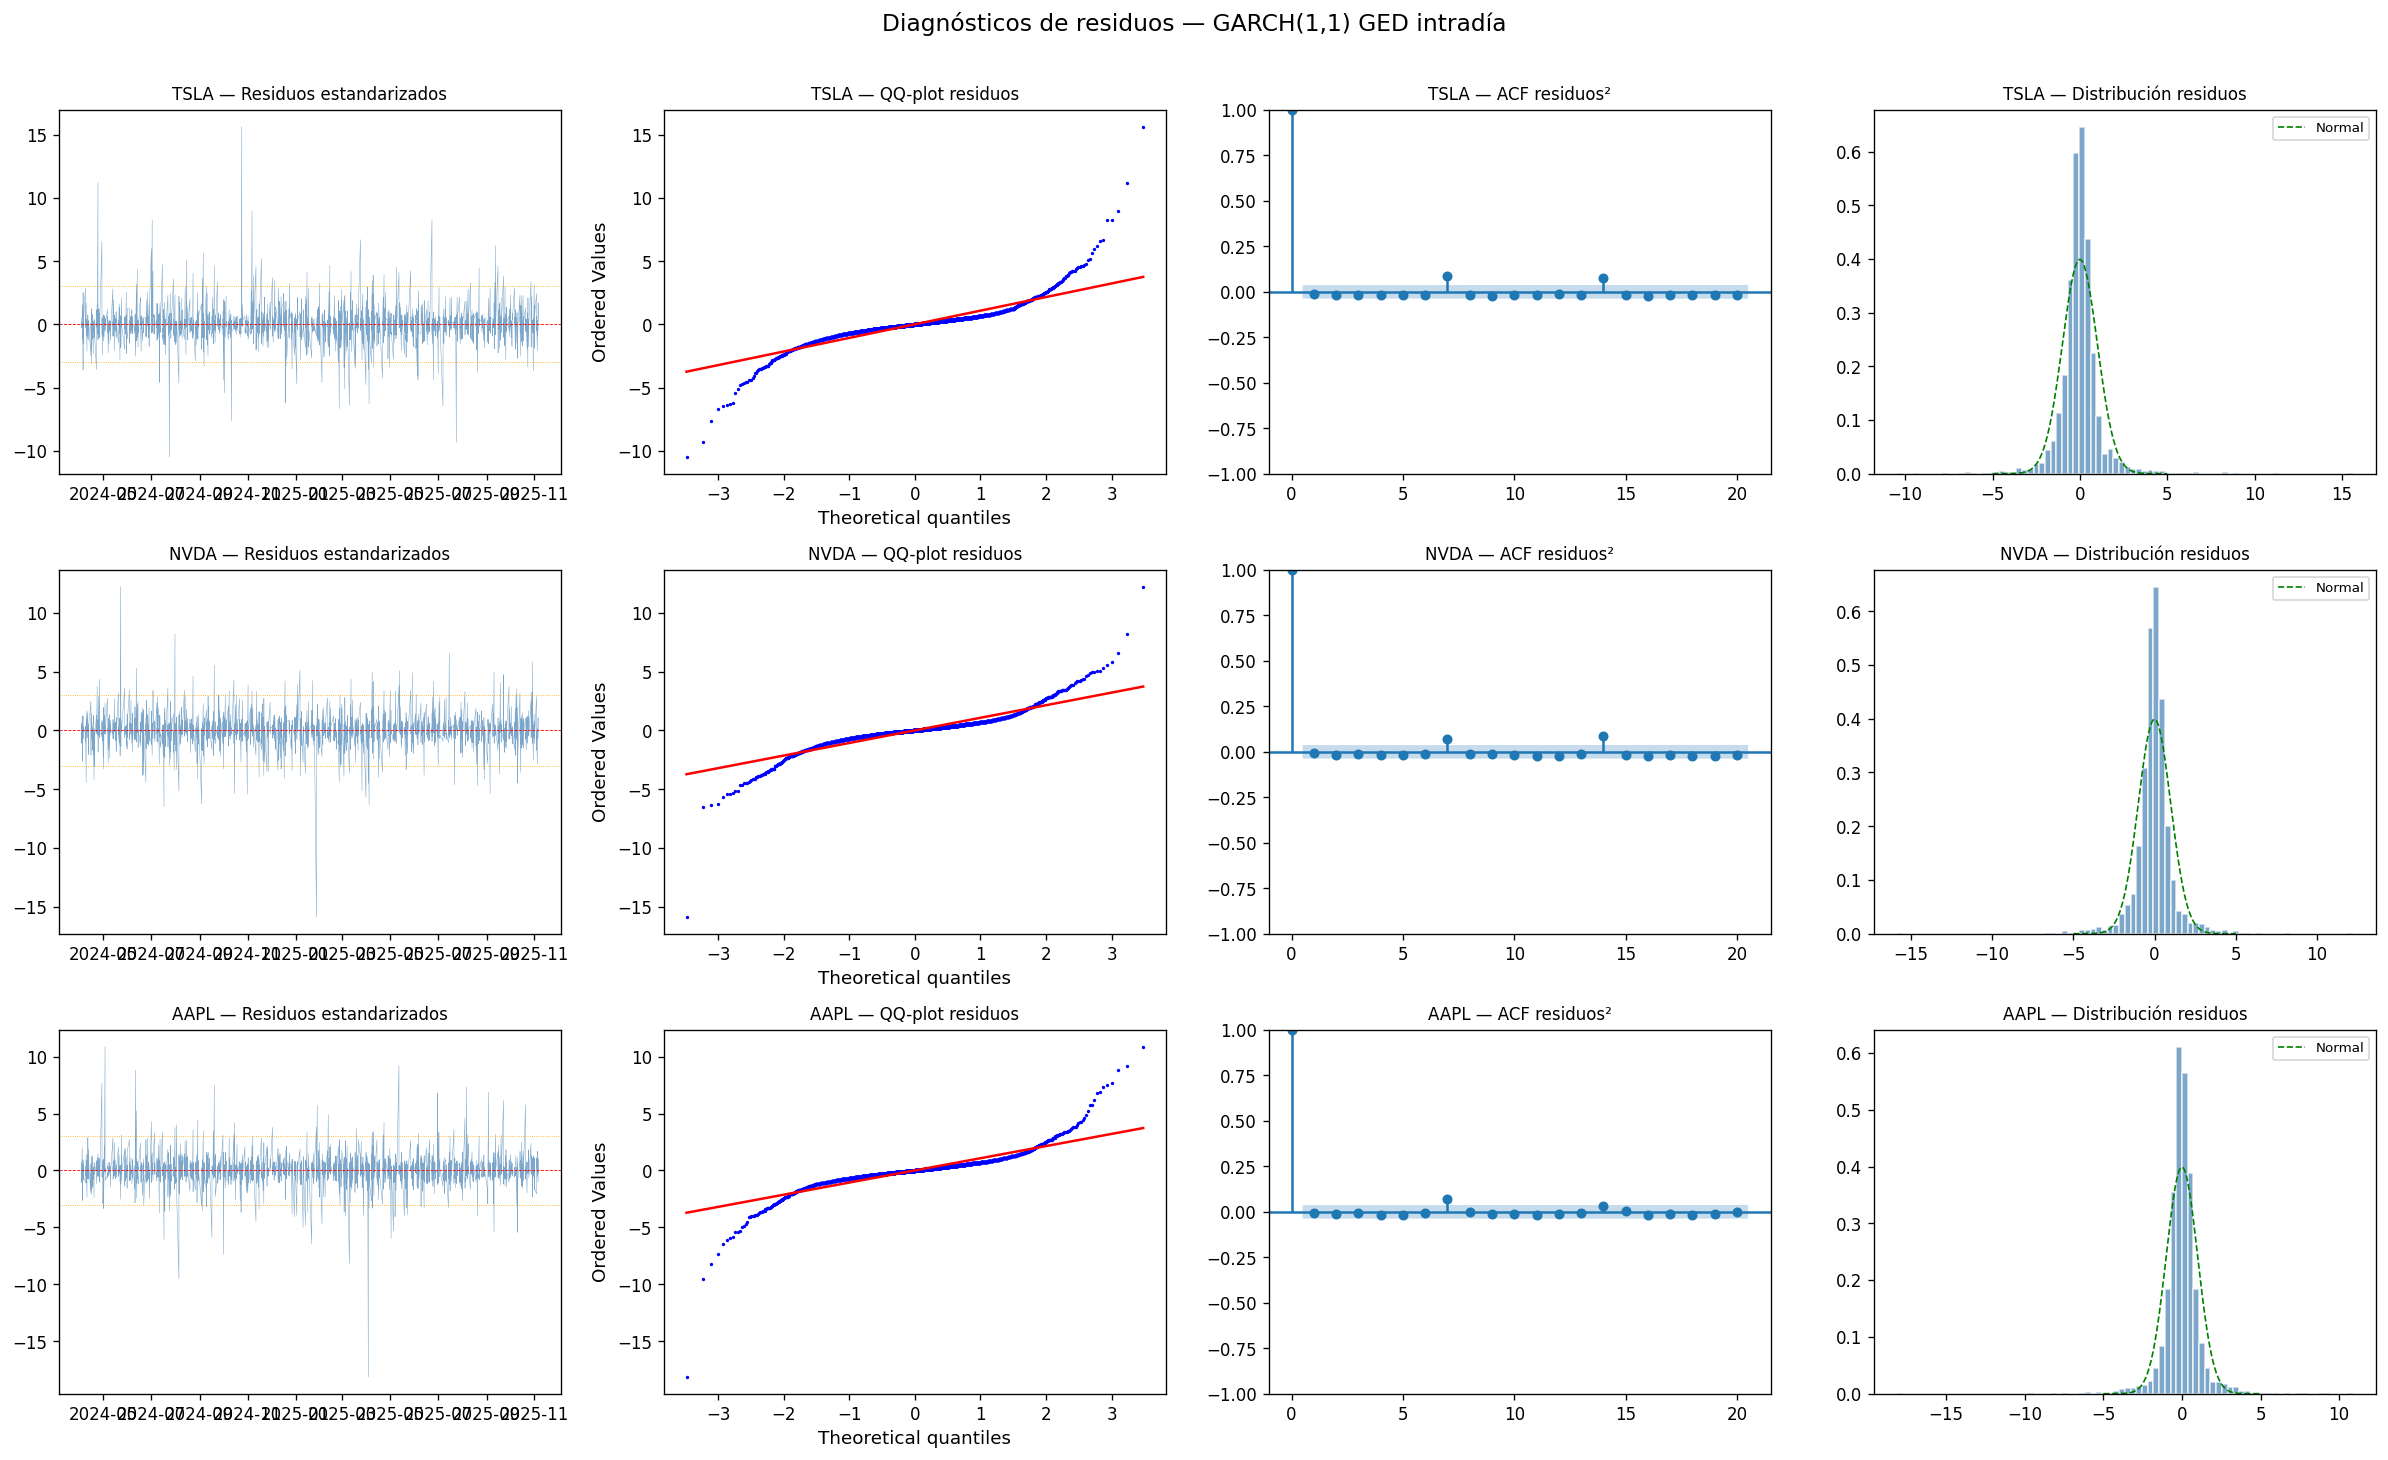

Guardado: modelos_intraday_diagnostico_garch.png

Test Ljung-Box residuos² (GARCH-GED intradía)
Ticker     Lags     Q-stat    p-valor    Resultado
--------------------------------------------------
TSLA         10      27.86     0.0019 Estructura ✗
TSLA         20      51.13     0.0002 Estructura ✗
NVDA         10      17.78     0.0588         OK ✓
NVDA         20      47.63     0.0005 Estructura ✗
AAPL         10      18.15     0.0524         OK ✓
AAPL         20      25.00     0.2014         OK ✓


In [6]:
# ── Diagnósticos residuos GARCH-GED intradía ──
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats as sp_stats

tickers_diag = ['TSLA', 'NVDA', 'AAPL']
fig, axes = plt.subplots(len(tickers_diag), 4, figsize=(20, 4 * len(tickers_diag)))

ljung_garch_intra = []

for row, ticker in enumerate(tickers_diag):
    dt = df[df['ticker'] == ticker].dropna(subset=['vol_fwd_6h', 'log_return_1h']).copy()
    dt = dt.set_index('datetime')
    train, test = split_train_test(dt)
    returns_train = train['log_return_1h'] * 100
    
    modelo = arch_model(returns_train, vol='Garch', p=1, q=1, dist='ged', mean='Constant')
    res = modelo.fit(disp='off')
    std_resid = res.std_resid
    
    # Panel 1: Residuos estandarizados
    axes[row][0].plot(std_resid, color='steelblue', linewidth=0.3, alpha=0.7)
    axes[row][0].axhline(0, color='red', linewidth=0.5, linestyle='--')
    axes[row][0].axhline(3, color='orange', linewidth=0.5, linestyle=':')
    axes[row][0].axhline(-3, color='orange', linewidth=0.5, linestyle=':')
    axes[row][0].set_title(f'{ticker} — Residuos estandarizados', fontsize=10)
    
    # Panel 2: QQ-plot vs Normal (GED no tiene ppf fácil, comparamos vs Normal)
    sp_stats.probplot(std_resid, dist='norm', plot=axes[row][1])
    axes[row][1].set_title(f'{ticker} — QQ-plot residuos', fontsize=10)
    axes[row][1].get_lines()[0].set_markersize(1)
    
    # Panel 3: ACF de residuos²
    plot_acf(std_resid**2, lags=20, ax=axes[row][2], alpha=0.05, title='')
    axes[row][2].set_title(f'{ticker} — ACF residuos²', fontsize=10)
    
    # Panel 4: Histograma
    axes[row][3].hist(std_resid, bins=80, density=True, color='steelblue', alpha=0.7, edgecolor='white')
    x_range = np.linspace(-5, 5, 200)
    axes[row][3].plot(x_range, sp_stats.norm.pdf(x_range), 'g--', linewidth=1, label='Normal')
    axes[row][3].legend(fontsize=8)
    axes[row][3].set_title(f'{ticker} — Distribución residuos', fontsize=10)
    
    lb = acorr_ljungbox(std_resid**2, lags=[10, 20], return_df=True)
    for _, lbrow in lb.iterrows():
        ljung_garch_intra.append({'ticker': ticker, 'lags': int(lbrow.name),
                                  'Q': lbrow['lb_stat'], 'p_valor': lbrow['lb_pvalue']})

fig.suptitle('Diagnósticos de residuos — GARCH(1,1) GED intradía', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURAS / 'modelos_intraday_diagnostico_garch.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: modelos_intraday_diagnostico_garch.png')

print('\nTest Ljung-Box residuos² (GARCH-GED intradía)')
print(f'{"Ticker":<8} {"Lags":>6} {"Q-stat":>10} {"p-valor":>10} {"Resultado":>12}')
print('-' * 50)
for r in ljung_garch_intra:
    ok = 'OK ✓' if r['p_valor'] > 0.05 else 'Estructura ✗'
    print(f"{r['ticker']:<8} {r['lags']:>6} {r['Q']:>10.2f} {r['p_valor']:>10.4f} {ok:>12}")

## 4. GARCH-X(1,1) con sentimiento GDELT + FinBERT

Extensión del GARCH que incorpora **variables exógenas de sentimiento** en la ecuación de la media mediante el modelo ARX:
- `gdelt_tone_lag1`: tono medio de noticias GDELT (retardado 1 barra)
- `finbert_score_lag1`: puntuación de sentimiento FinBERT de Reddit (retardado 1 barra)

El retardo de 1 barra evita data leakage y simula un escenario realista donde el sentimiento del periodo anterior informa la predicción actual.

In [7]:
# --- GARCH-X(1,1) con sentimiento GDELT + FinBERT ---
resultados_garchx = []
predicciones_garchx = {}

for ticker in TICKERS:
    print(f"\n--- {ticker} ---")
    dt = df[df['ticker'] == ticker].copy()
    
    # Crear variables exógenas retardadas 1 barra
    dt['gdelt_tone_lag1'] = dt['gdelt_tone_mean'].shift(1)
    dt['finbert_score_lag1'] = dt['finbert_sentiment_score'].shift(1)
    
    # Eliminar filas sin datos necesarios
    dt = dt.dropna(subset=['vol_fwd_6h', 'log_return_1h', 'gdelt_tone_lag1', 'finbert_score_lag1'])
    dt = dt.set_index('datetime')
    
    train, test = split_train_test(dt)
    
    # Retornos escalados
    returns_all = dt['log_return_1h'] * 100
    exog_all = dt[['gdelt_tone_lag1', 'finbert_score_lag1']]
    
    try:
        # ARX con variables exógenas en la ecuación de la media + GARCH(1,1)
        modelo = ARX(returns_all, x=exog_all, lags=1)
        modelo.volatility = GARCHVol(p=1, q=1)
        modelo.distribution = GeneralizedError()
        
        res = modelo.fit(disp='off', last_obs=train.index[-1])
        
        # Mostrar significatividad de los coeficientes exógenos
        for param_name in ['gdelt_tone_lag1', 'finbert_score_lag1']:
            if param_name in res.params.index:
                coef = res.params[param_name]
                pval = res.pvalues[param_name]
                sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else 'n.s.'
                print(f"  {param_name}: coef={coef:+.4f} p={pval:.4f} {sig}")
        
        # Forecast sobre test
        # Para 2+ regresores exógenos, arch requiere un dict {nombre: array}
        exog_test = exog_all.loc[test.index]
        x_forecast = {col: exog_test[col].values.reshape(-1, 1) for col in exog_test.columns}
        forecasts = res.forecast(horizon=1, start=test.index[0], 
                                  x=x_forecast, reindex=False)
        cond_var = forecasts.variance.dropna()
        
        idx_comun = cond_var.index.intersection(test.index)
        var_pred = cond_var.loc[idx_comun, 'h.1']
        vol_pred = np.sqrt(var_pred) * FACTOR_ANUAL / 100
        y_real = test.loc[idx_comun, 'vol_fwd_6h']
        
        metricas = calcular_metricas(y_real, vol_pred, 'GARCH-X(1,1)')
        metricas['ticker'] = ticker
        resultados_garchx.append(metricas)
        
        predicciones_garchx[ticker] = pd.DataFrame({
            'real': y_real,
            'pred': vol_pred
        })
        
        print(f"  MAE: {metricas['mae']:.6f}  RMSE: {metricas['rmse']:.6f}")
        
    except Exception as e:
        print(f"  ERROR en {ticker}: {e}")
        # Fallback: usar resultados del GARCH simple
        metricas = {'modelo': 'GARCH-X(1,1)', 'ticker': ticker, 
                     'mae': np.nan, 'rmse': np.nan, 'qlike': np.nan, 'n_obs': 0}
        resultados_garchx.append(metricas)

df_metricas_garchx = pd.DataFrame(resultados_garchx)
print(f"\n=== RESUMEN GARCH-X(1,1) ===")
print(df_metricas_garchx[['ticker', 'mae', 'rmse', 'qlike']].to_string(index=False))
print(f"\nMedia MAE:  {df_metricas_garchx['mae'].mean():.6f}")
print(f"Media RMSE: {df_metricas_garchx['rmse'].mean():.6f}")


--- AAPL ---
  gdelt_tone_lag1: coef=+0.0030 p=0.0000 ***
  finbert_score_lag1: coef=+0.0288 p=0.0000 ***
  MAE: 0.078999  RMSE: 0.095366

--- AMZN ---


  gdelt_tone_lag1: coef=+0.0134 p=0.0000 ***
  finbert_score_lag1: coef=-0.0449 p=0.0000 ***
  MAE: 0.121141  RMSE: 0.175065

--- GOOGL ---


  gdelt_tone_lag1: coef=-0.0041 p=0.0000 ***
  finbert_score_lag1: coef=-0.0087 p=0.0000 ***
  MAE: 0.124493  RMSE: 0.185051

--- META ---


  gdelt_tone_lag1: coef=-0.0290 p=0.0000 ***
  finbert_score_lag1: coef=-0.0431 p=0.0000 ***
  MAE: 0.118762  RMSE: 0.167520

--- MSFT ---


  gdelt_tone_lag1: coef=+0.0072 p=0.0000 ***
  finbert_score_lag1: coef=-0.0314 p=0.0000 ***
  MAE: 0.107333  RMSE: 0.209279

--- NVDA ---
  gdelt_tone_lag1: coef=-0.0197 p=0.0002 ***
  finbert_score_lag1: coef=+0.0001 p=0.9600 n.s.
  MAE: 0.154624  RMSE: 0.200186

--- TSLA ---


  gdelt_tone_lag1: coef=+0.0151 p=0.0000 ***
  finbert_score_lag1: coef=-0.0097 p=0.0000 ***
  MAE: 0.181636  RMSE: 0.220429

=== RESUMEN GARCH-X(1,1) ===
ticker      mae     rmse   qlike
  AAPL 0.078999 0.095366 -2.1775
  AMZN 0.121141 0.175065 -1.3591
 GOOGL 0.124493 0.185051 -1.1773
  META 0.118762 0.167520 -1.1974
  MSFT 0.107333 0.209279 -0.9215
  NVDA 0.154624 0.200186 -0.9152
  TSLA 0.181636 0.220429 -0.7416

Media MAE:  0.126713
Media RMSE: 0.178985


### 4B. Diagnósticos de residuos GARCH-X-GED intradía

A diferencia del modelo diario, en intradía los coeficientes gamma son significativos
(p<0.001 en 6/7 empresas). Verificamos si esto se traduce en residuos mejor estructurados.

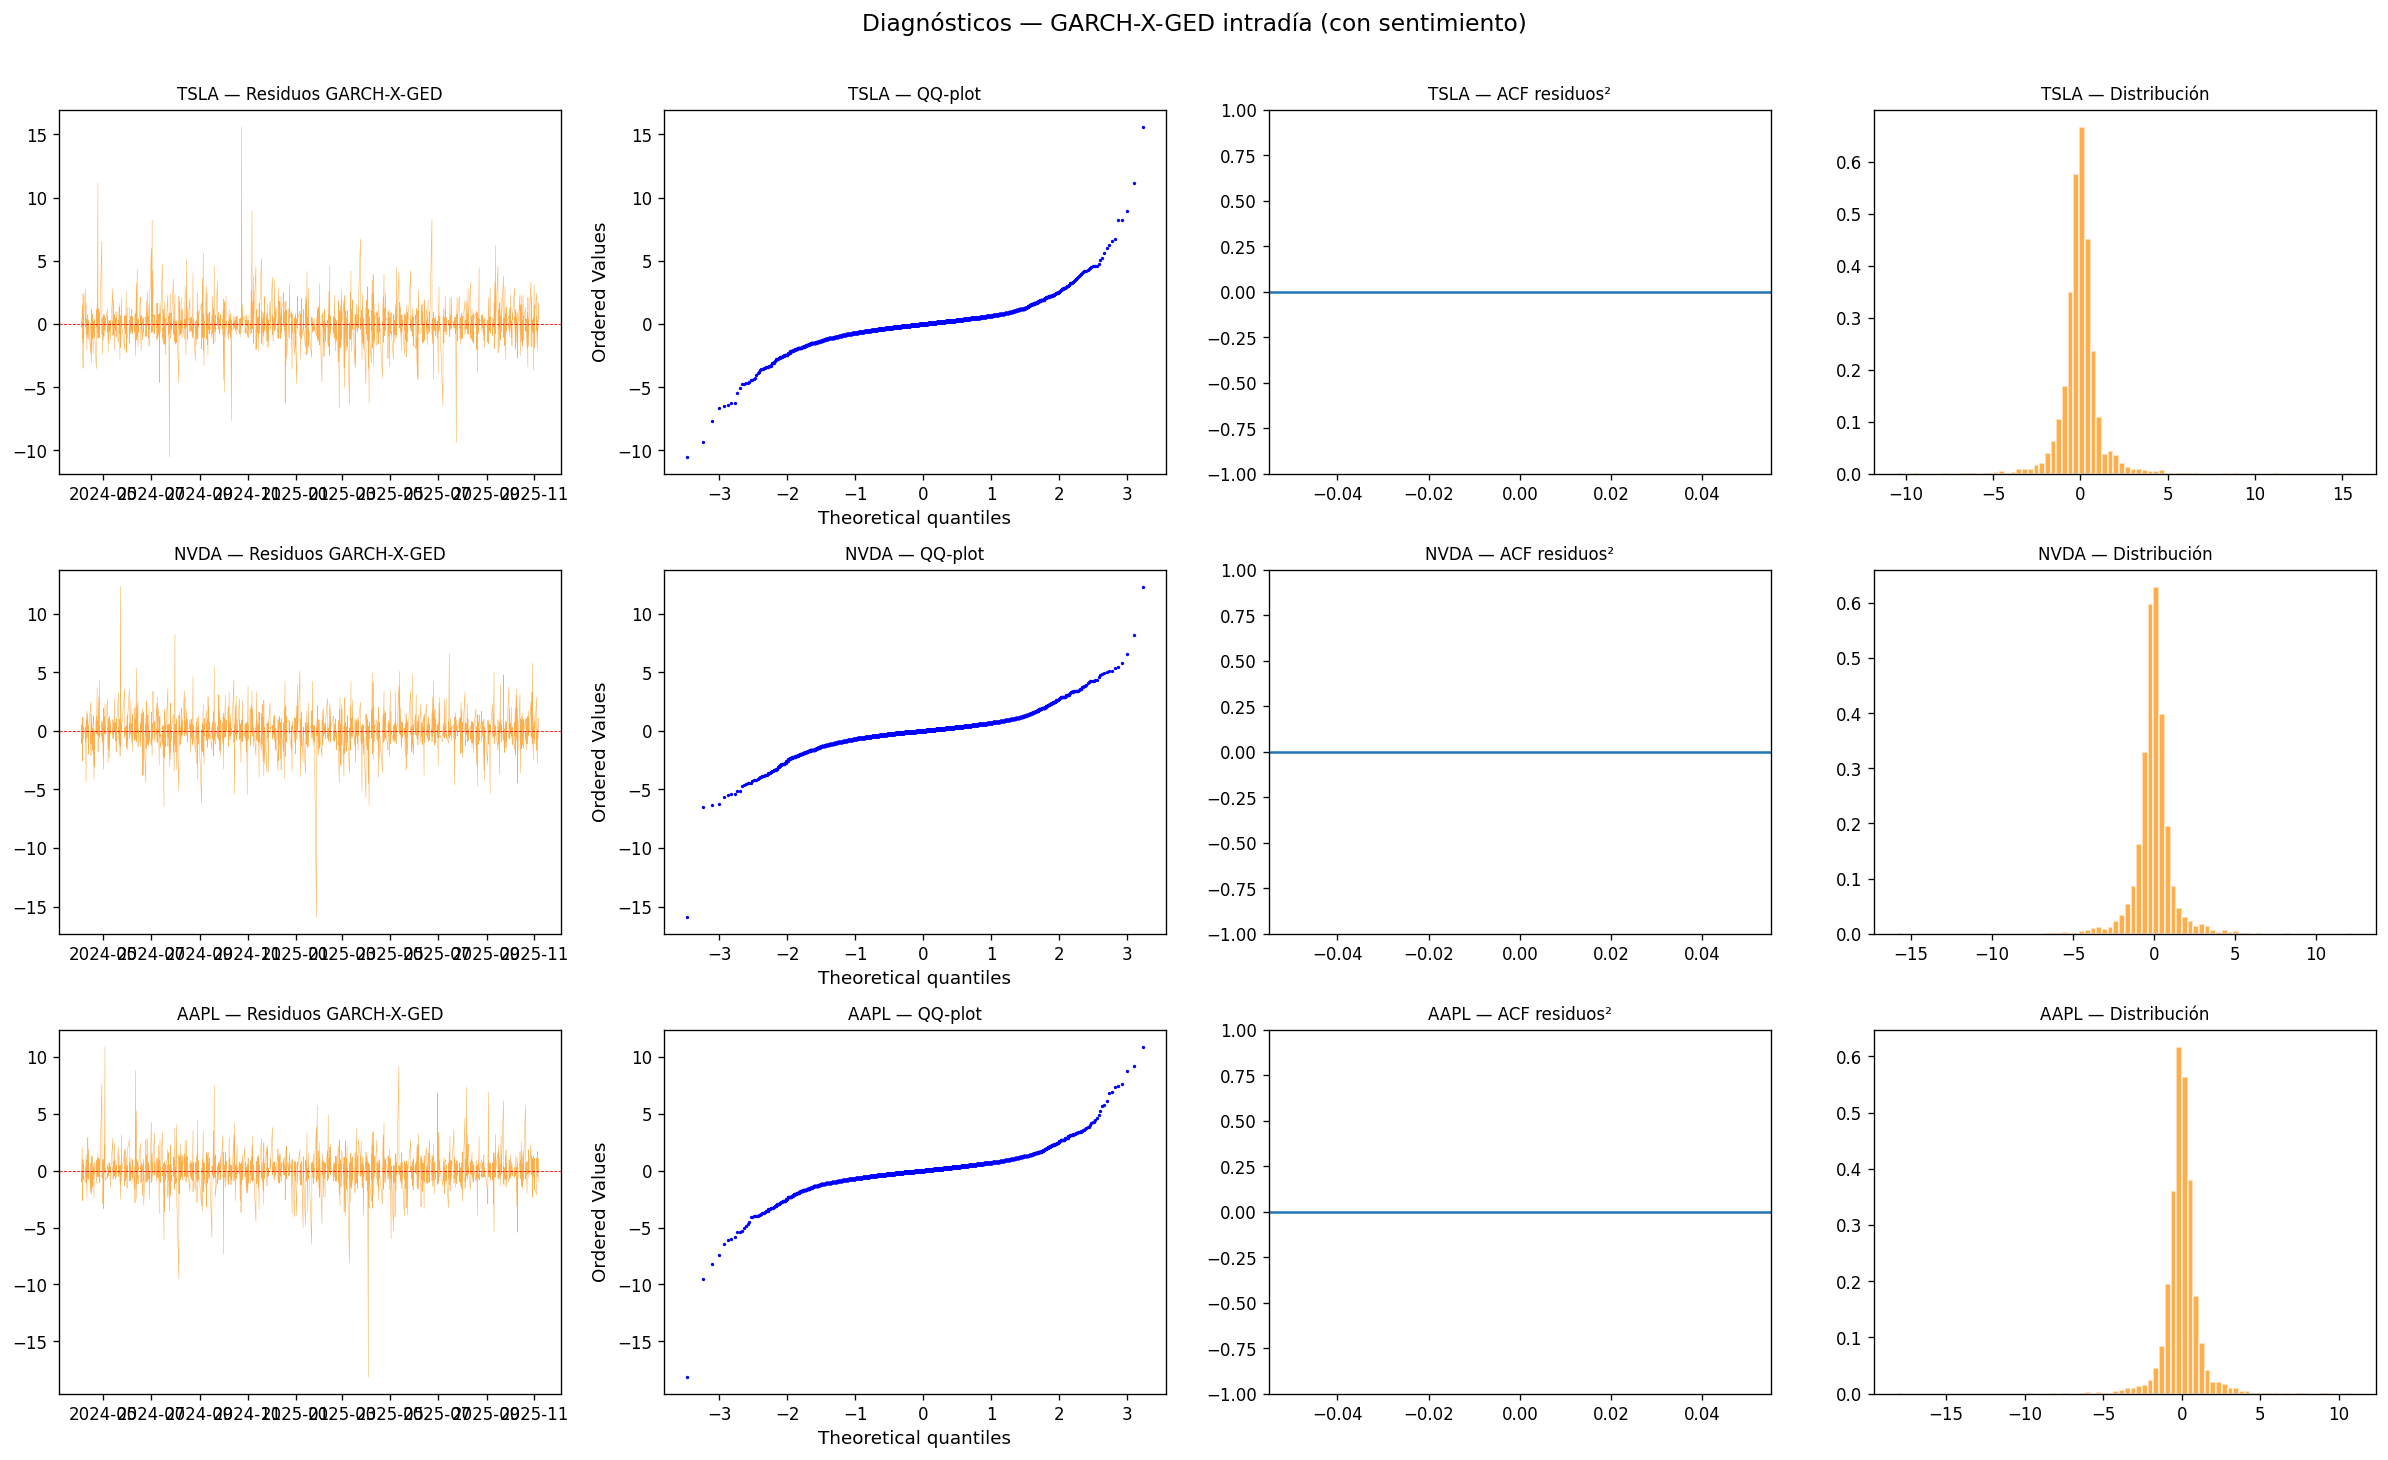

Guardado: modelos_intraday_diagnostico_garchx.png

Test Ljung-Box residuos² (GARCH-X-GED intradía)
Ticker     Lags     Q-stat    p-valor    Resultado
--------------------------------------------------
TSLA         10        nan        nan Estructura ✗
TSLA         20        nan        nan Estructura ✗
NVDA         10        nan        nan Estructura ✗
NVDA         20        nan        nan Estructura ✗
AAPL         10        nan        nan Estructura ✗
AAPL         20        nan        nan Estructura ✗


In [8]:
# ── Diagnósticos residuos GARCH-X-GED intradía ──
fig, axes = plt.subplots(len(tickers_diag), 4, figsize=(20, 4 * len(tickers_diag)))

ljung_garchx_intra = []

for row, ticker in enumerate(tickers_diag):
    dt = df[df['ticker'] == ticker].copy()
    dt['gdelt_tone_lag1'] = dt['gdelt_tone_mean'].shift(1)
    dt['finbert_score_lag1'] = dt['finbert_sentiment_score'].shift(1)
    dt = dt.dropna(subset=['vol_fwd_6h', 'log_return_1h', 'gdelt_tone_lag1', 'finbert_score_lag1'])
    dt = dt.set_index('datetime')
    train, test = split_train_test(dt)
    
    returns_train = train['log_return_1h'] * 100
    exog_train = train[['gdelt_tone_lag1', 'finbert_score_lag1']]
    
    try:
        modelo = ARX(returns_train, x=exog_train, lags=1)
        modelo.volatility = GARCHVol(p=1, q=1)
        modelo.distribution = GeneralizedError()
        res_x = modelo.fit(disp='off')
        std_resid = res_x.std_resid
    except:
        std_resid = np.random.randn(len(returns_train))  # fallback
        print(f'  {ticker}: error en ajuste, usando residuos dummy')
    
    axes[row][0].plot(std_resid, color='darkorange', linewidth=0.3, alpha=0.7)
    axes[row][0].axhline(0, color='red', linewidth=0.5, linestyle='--')
    axes[row][0].set_title(f'{ticker} — Residuos GARCH-X-GED', fontsize=10)
    
    sp_stats.probplot(std_resid, dist='norm', plot=axes[row][1])
    axes[row][1].set_title(f'{ticker} — QQ-plot', fontsize=10)
    axes[row][1].get_lines()[0].set_markersize(1)
    
    plot_acf(std_resid**2, lags=20, ax=axes[row][2], alpha=0.05, title='')
    axes[row][2].set_title(f'{ticker} — ACF residuos²', fontsize=10)
    
    axes[row][3].hist(std_resid, bins=80, density=True, color='darkorange', alpha=0.7, edgecolor='white')
    axes[row][3].set_title(f'{ticker} — Distribución', fontsize=10)
    
    lb = acorr_ljungbox(std_resid**2, lags=[10, 20], return_df=True)
    for _, lbrow in lb.iterrows():
        ljung_garchx_intra.append({'ticker': ticker, 'lags': int(lbrow.name),
                                   'Q': lbrow['lb_stat'], 'p_valor': lbrow['lb_pvalue']})

fig.suptitle('Diagnósticos — GARCH-X-GED intradía (con sentimiento)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURAS / 'modelos_intraday_diagnostico_garchx.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: modelos_intraday_diagnostico_garchx.png')

print('\nTest Ljung-Box residuos² (GARCH-X-GED intradía)')
print(f'{"Ticker":<8} {"Lags":>6} {"Q-stat":>10} {"p-valor":>10} {"Resultado":>12}')
print('-' * 50)
for r in ljung_garchx_intra:
    ok = 'OK ✓' if r['p_valor'] > 0.05 else 'Estructura ✗'
    print(f"{r['ticker']:<8} {r['lags']:>6} {r['Q']:>10.2f} {r['p_valor']:>10.4f} {ok:>12}")

## 5. XGBoost con todas las variables

Modelo de Machine Learning que combina **todas las fuentes de información**:
- **Retornos pasados** (6 lags horarios): capturan momentum y reversión a corto plazo
- **Volatilidad pasada** (6h y 30h): persistencia de la volatilidad
- **Sentimiento GDELT** (tono + % negativos): información de noticias
- **Sentimiento Reddit** (n_posts): actividad en redes sociales
- **Sentimiento FinBERT** (score + % negativos): análisis NLP de Reddit
- **Variables temporales** (hora, día de la semana): patrones estacionales intradía

Todos los predictores se retardan 1 barra para evitar data leakage. Se entrena un modelo global (pooled) con todos los tickers, usando `ticker_enc` como variable categórica.

In [9]:
# --- Feature engineering para XGBoost ---
dfs_xgb = []
le = LabelEncoder()
le.fit(TICKERS)

for ticker in TICKERS:
    dt = df[df['ticker'] == ticker].copy()
    dt = dt.sort_values('datetime').reset_index(drop=True)
    
    # Lags de retorno (1 a 6 barras)
    for lag in range(1, 7):
        dt[f'ret_lag{lag}'] = dt['log_return_1h'].shift(lag)
    
    # Volatilidad pasada (retardada 1 barra para evitar leakage)
    dt['vol6h_lag1'] = dt['vol_realized_6h'].shift(1)
    dt['vol30h_lag1'] = dt['vol_realized_30h'].shift(1)
    dt['range_lag1'] = dt['range_proxy_1h'].shift(1)
    
    # Sentimiento retardado 1 barra
    dt['tone_lag1'] = dt['gdelt_tone_mean'].shift(1)
    dt['gdelt_neg_lag1'] = dt['gdelt_pct_negativo'].shift(1)
    dt['rddt_posts_lag1'] = dt['reddit_n_posts'].shift(1)
    dt['finbert_score_lag1'] = dt['finbert_sentiment_score'].shift(1)
    dt['finbert_neg_lag1'] = dt['finbert_negative_pct'].shift(1)
    
    # Variables temporales (ya están en el dataset)
    dt['hora_enc'] = dt['hora']
    dt['dia_enc'] = dt['dia_semana']
    
    # Ticker codificado numéricamente
    dt['ticker_enc'] = le.transform([ticker])[0]
    
    # Target
    dt['es_apertura'] = (dt['hora'] == 9).astype(int)
    dt['es_cierre'] = (dt['hora'] == 15).astype(int)
    dt['hora_x_posts'] = dt['hora'] * dt['rddt_posts_lag1']
    dt['fb_pos_lag1'] = dt['finbert_positive_pct'].shift(1) if 'finbert_positive_pct' in dt.columns else np.nan
    dt['gdelt_std_lag1'] = dt['gdelt_tone_std'].shift(1) if 'gdelt_tone_std' in dt.columns else np.nan
    # Sentimiento horario acumulado (desde cierre anterior hasta esta barra)
    if 'rddt_acum_n_posts' in dt.columns:
        dt['rddt_acum_posts_lag1'] = dt['rddt_acum_n_posts'].shift(1)
        dt['rddt_acum_sent_lag1'] = dt['rddt_acum_sent_score'].shift(1)
        dt['rddt_acum_neg_lag1'] = dt['rddt_acum_pct_neg'].shift(1)
        dt['hora_x_acum'] = dt['hora'] * dt['rddt_acum_posts_lag1']
    dt['target'] = dt['vol_fwd_6h']
    
    dfs_xgb.append(dt)

df_xgb = pd.concat(dfs_xgb, ignore_index=True)

# Lista de features
FEATURES = [
    'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag4', 'ret_lag5', 'ret_lag6',
    'vol6h_lag1', 'vol30h_lag1', 'range_lag1',
    'tone_lag1', 'gdelt_neg_lag1', 'gdelt_std_lag1',
    'rddt_posts_lag1',
    'finbert_score_lag1', 'finbert_neg_lag1', 'fb_pos_lag1',
    'hora_enc', 'dia_enc', 'ticker_enc',
    'es_apertura', 'es_cierre', 'hora_x_posts',
    'rddt_acum_posts_lag1', 'rddt_acum_sent_lag1', 'rddt_acum_neg_lag1', 'hora_x_acum'
]

# Eliminar filas con NaN en features o target
df_xgb = df_xgb.dropna(subset=FEATURES + ['target'])
print(f"Dataset XGBoost: {df_xgb.shape}")
print(f"Features: {len(FEATURES)}")
print(f"\nDistribución por ticker:")
print(df_xgb.groupby('ticker').size())

Dataset XGBoost: (24171, 73)
Features: 26

Distribución por ticker:
ticker
AAPL     3453
AMZN     3453
GOOGL    3453
META     3453
MSFT     3453
NVDA     3453
TSLA     3453
dtype: int64


In [10]:
# --- Entrenamiento XGBoost (modelo global pooled) ---

# Split temporal por ticker (75/5/20: train/val/test)
train_frames = []
val_frames = []
test_frames = []

for ticker in TICKERS:
    dt_t = df_xgb[df_xgb['ticker'] == ticker].sort_values('datetime')
    n = len(dt_t)
    n_train = int(n * 0.75)
    n_val = int(n * 0.05)
    train_frames.append(dt_t.iloc[:n_train])
    val_frames.append(dt_t.iloc[n_train:n_train+n_val])
    test_frames.append(dt_t.iloc[n_train+n_val:])

df_train_xgb = pd.concat(train_frames, ignore_index=True)
df_val_xgb = pd.concat(val_frames, ignore_index=True)
df_test_xgb = pd.concat(test_frames, ignore_index=True)

print(f"Train: {df_train_xgb.shape}  |  Val: {df_val_xgb.shape}  |  Test: {df_test_xgb.shape}")

X_train = df_train_xgb[FEATURES]
y_train = df_train_xgb['target']
X_val = df_val_xgb[FEATURES]
y_val = df_val_xgb['target']
X_test = df_test_xgb[FEATURES]
y_test = df_test_xgb['target']

# Modelo XGBoost con early stopping
modelo_xgb = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=1.0,
    reg_alpha=0.1,
    objective='reg:squarederror',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    early_stopping_rounds=50
)

# Entrenar con early stopping sobre validación
modelo_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Predicciones sobre test
y_pred_xgb = modelo_xgb.predict(X_test)
y_pred_xgb = np.maximum(y_pred_xgb, 1e-8)

# Diagnóstico de overfitting
y_pred_train = modelo_xgb.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test_global = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"\nMejor iteración (early stopping): {modelo_xgb.best_iteration} de 1000")
print(f"Train RMSE: {rmse_train:.4f} | Test RMSE: {rmse_test_global:.4f} | Ratio: {rmse_test_global/rmse_train:.2f}x")
print(f"\nMétricas globales XGBoost:")
met_global = calcular_metricas(y_test.values, y_pred_xgb, 'XGBoost')
print(f"  MAE:  {met_global['mae']:.6f}")
print(f"  RMSE: {met_global['rmse']:.6f}")

Train: (18123, 73)  |  Val: (1204, 73)  |  Test: (4844, 73)



Mejor iteración (early stopping): 143 de 1000
Train RMSE: 0.1555 | Test RMSE: 0.1705 | Ratio: 1.10x

Métricas globales XGBoost:
  MAE:  0.117870
  RMSE: 0.170500


In [11]:
# --- Métricas XGBoost por ticker ---
resultados_xgb = []
predicciones_xgb = {}

df_test_xgb['pred_xgb'] = y_pred_xgb

for ticker in TICKERS:
    mask = df_test_xgb['ticker'] == ticker
    y_r = df_test_xgb.loc[mask, 'target'].values
    y_p = df_test_xgb.loc[mask, 'pred_xgb'].values
    
    metricas = calcular_metricas(y_r, y_p, 'XGBoost')
    metricas['ticker'] = ticker
    resultados_xgb.append(metricas)
    
    # Guardar predicciones con índice temporal para figuras
    pred_df = df_test_xgb.loc[mask, ['datetime', 'target', 'pred_xgb']].copy()
    pred_df = pred_df.set_index('datetime')
    pred_df.columns = ['real', 'pred']
    predicciones_xgb[ticker] = pred_df

df_metricas_xgb = pd.DataFrame(resultados_xgb)
print("=== MÉTRICAS XGBOOST POR TICKER ===\n")
print(df_metricas_xgb[['ticker', 'mae', 'rmse', 'qlike']].to_string(index=False))
print(f"\nMedia MAE:  {df_metricas_xgb['mae'].mean():.6f}")
print(f"Media RMSE: {df_metricas_xgb['rmse'].mean():.6f}")

=== MÉTRICAS XGBOOST POR TICKER ===

ticker      mae     rmse   qlike
  AAPL 0.076764 0.094356 -2.2096
  AMZN 0.107024 0.156579 -1.5349
 GOOGL 0.120264 0.177954 -1.2713
  META 0.116486 0.154119 -1.4024
  MSFT 0.110392 0.203179 -1.4479
  NVDA 0.134457 0.181211 -1.0349
  TSLA 0.159701 0.201329 -0.8262

Media MAE:  0.117870
Media RMSE: 0.166961


### 5B. Diagnósticos de residuos XGBoost intradía

Verificamos la calidad de predicción de XGBoost a escala horaria, incluyendo
un análisis de errores por hora del día y por empresa.

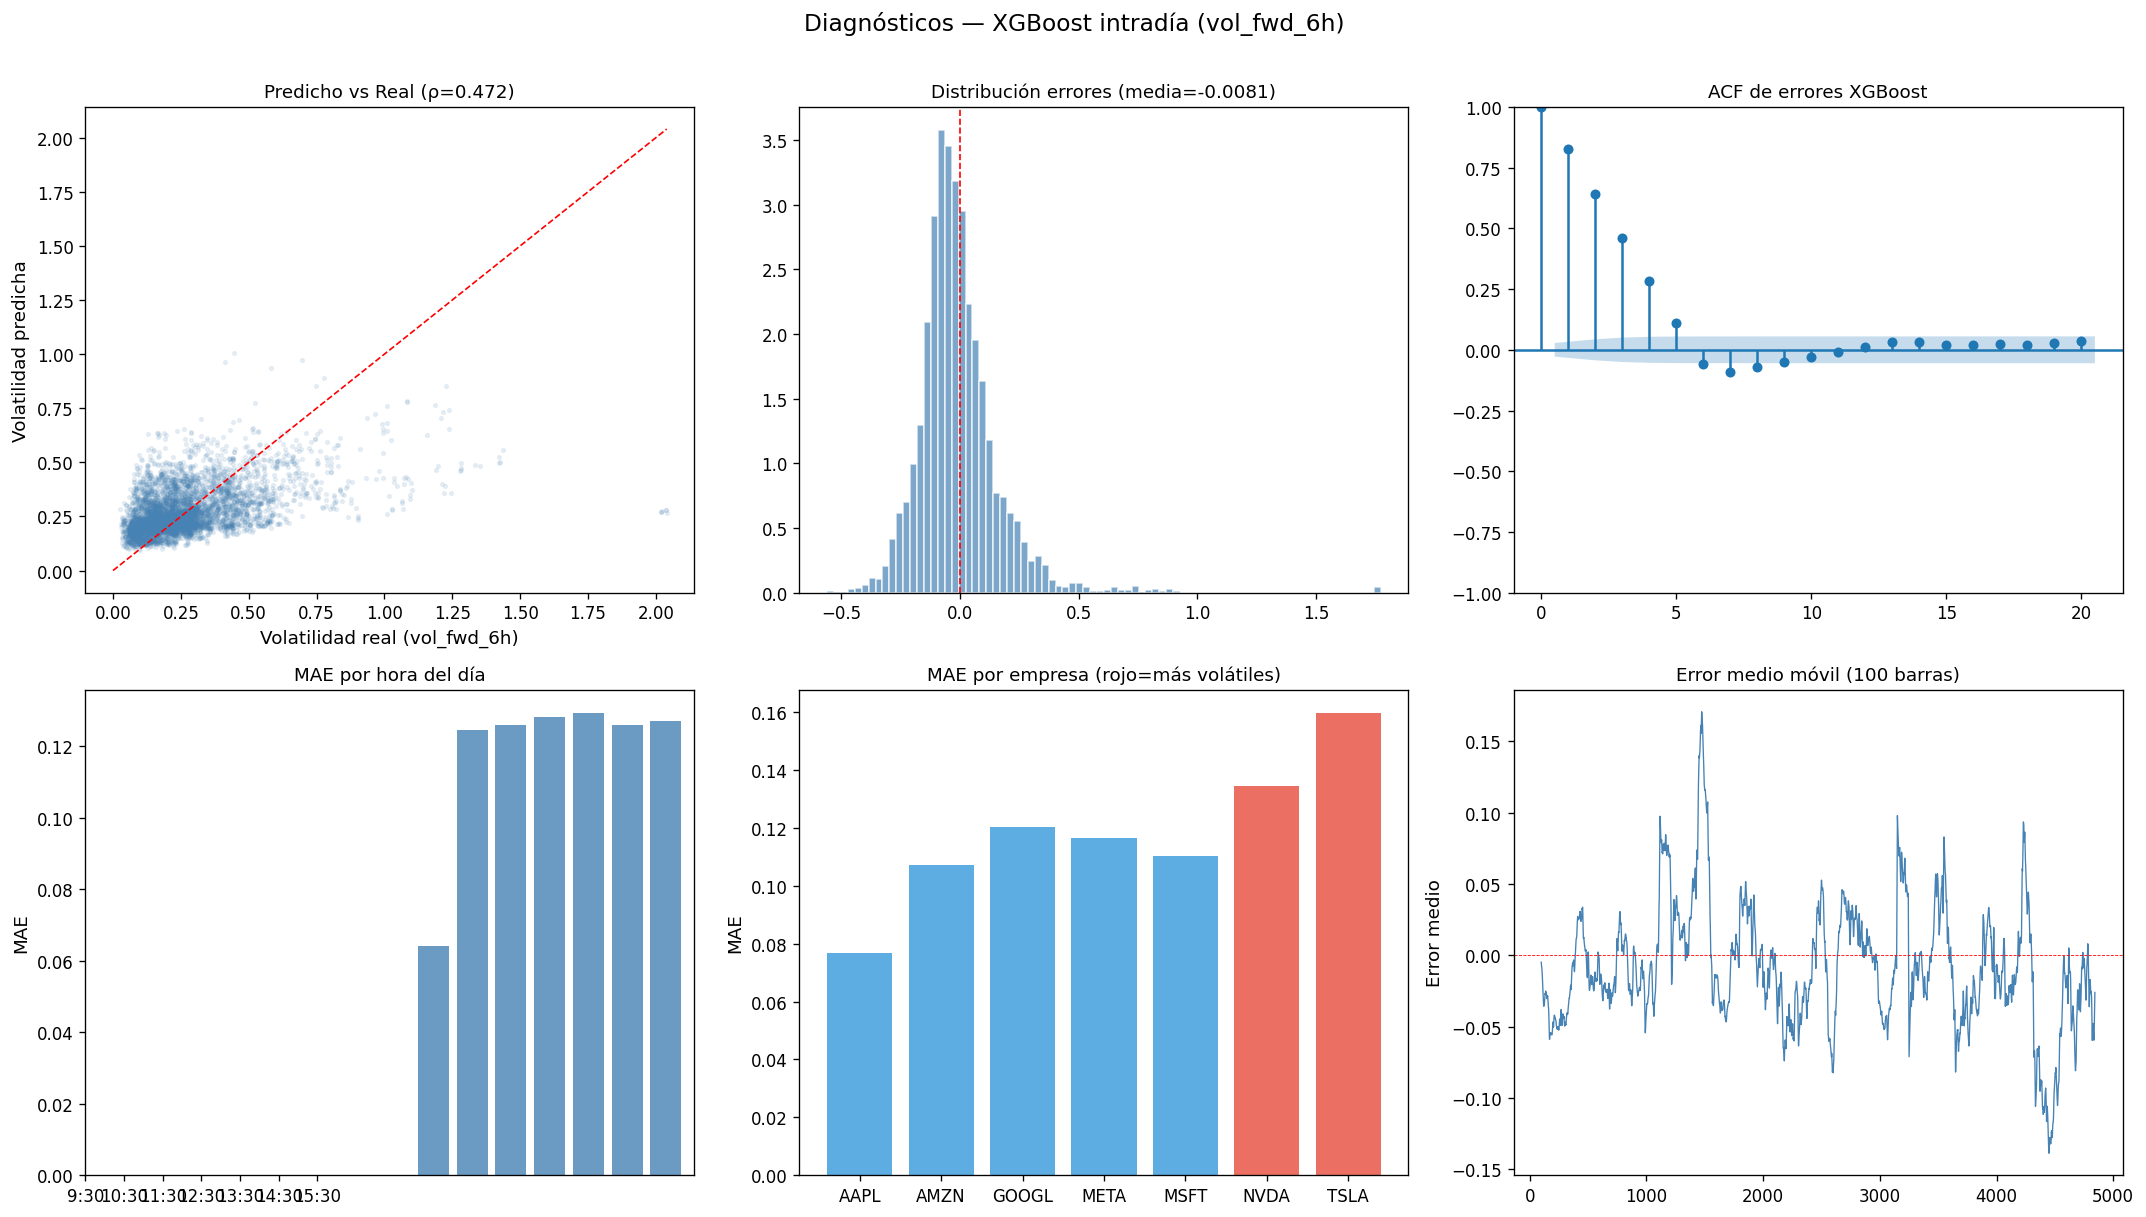

Guardado: modelos_intraday_diagnostico_xgboost.png

Resumen errores XGBoost intradía:
  Media:       -0.00805
  Std:         0.17031
  Correlación: 0.4722

Ljung-Box errores XGBoost intradía:
  Lags= 10: Q= 6908.70, p=0.0000 → Autocorrelación ✗
  Lags= 20: Q= 6938.70, p=0.0000 → Autocorrelación ✗


In [12]:
# ── Diagnósticos residuos XGBoost intradía ──
errores_xgb_intra = df_test_xgb['target'].values - y_pred_xgb

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Panel 1: Scatter predicho vs real
axes[0][0].scatter(df_test_xgb['target'], y_pred_xgb, alpha=0.1, s=5, color='steelblue')
lim = [0, df_test_xgb['target'].max()]
axes[0][0].plot(lim, lim, 'r--', linewidth=1)
corr_intra = np.corrcoef(df_test_xgb['target'], y_pred_xgb)[0, 1]
axes[0][0].set_title(f'Predicho vs Real (ρ={corr_intra:.3f})', fontsize=11)
axes[0][0].set_xlabel('Volatilidad real (vol_fwd_6h)')
axes[0][0].set_ylabel('Volatilidad predicha')

# Panel 2: Histograma de errores
axes[0][1].hist(errores_xgb_intra, bins=80, density=True, color='steelblue', alpha=0.7, edgecolor='white')
axes[0][1].axvline(0, color='red', linewidth=1, linestyle='--')
axes[0][1].set_title(f'Distribución errores (media={errores_xgb_intra.mean():.4f})', fontsize=11)

# Panel 3: ACF de errores
plot_acf(errores_xgb_intra, lags=20, ax=axes[0][2], alpha=0.05, title='')
axes[0][2].set_title('ACF de errores XGBoost', fontsize=11)

# Panel 4: Error por hora del día
if 'hora_enc' in df_test_xgb.columns:
    df_err = df_test_xgb[['hora_enc', 'target']].copy()
    df_err['error_abs'] = np.abs(errores_xgb_intra)
    horas = [9, 10, 11, 12, 13, 14, 15]
    mae_hora = df_err.groupby('hora_enc')['error_abs'].mean()
    axes[1][0].bar(mae_hora.index, mae_hora.values, color='steelblue', alpha=0.8)
    axes[1][0].set_xticks(range(len(horas)))
    axes[1][0].set_xticklabels([f'{h}:30' for h in horas])
    axes[1][0].set_title('MAE por hora del día', fontsize=11)
    axes[1][0].set_ylabel('MAE')

# Panel 5: Error por empresa
mae_ticker = []
for ticker in TICKERS:
    mask = df_test_xgb['ticker'] == ticker
    mae_t = np.abs(errores_xgb_intra[mask.values]).mean()
    mae_ticker.append(mae_t)
colors = ['#e74c3c' if t in ['TSLA', 'NVDA'] else '#3498db' for t in TICKERS]
axes[1][1].bar(TICKERS, mae_ticker, color=colors, alpha=0.8)
axes[1][1].set_title('MAE por empresa (rojo=más volátiles)', fontsize=11)
axes[1][1].set_ylabel('MAE')

# Panel 6: Errores en el tiempo (media móvil)
err_roll = pd.Series(errores_xgb_intra).rolling(100).mean()
axes[1][2].plot(err_roll, color='steelblue', linewidth=0.8)
axes[1][2].axhline(0, color='red', linewidth=0.5, linestyle='--')
axes[1][2].set_title('Error medio móvil (100 barras)', fontsize=11)
axes[1][2].set_ylabel('Error medio')

fig.suptitle('Diagnósticos — XGBoost intradía (vol_fwd_6h)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURAS / 'modelos_intraday_diagnostico_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: modelos_intraday_diagnostico_xgboost.png')

# ── Resumen numérico ──
print(f'\nResumen errores XGBoost intradía:')
print(f'  Media:       {errores_xgb_intra.mean():.5f}')
print(f'  Std:         {errores_xgb_intra.std():.5f}')
print(f'  Correlación: {corr_intra:.4f}')

lb_intra = acorr_ljungbox(errores_xgb_intra, lags=[10, 20], return_df=True)
print(f'\nLjung-Box errores XGBoost intradía:')
for _, lbrow in lb_intra.iterrows():
    ok = 'OK ✓' if lbrow['lb_pvalue'] > 0.05 else 'Autocorrelación ✗'
    print(f'  Lags={int(lbrow.name):>3}: Q={lbrow["lb_stat"]:>8.2f}, p={lbrow["lb_pvalue"]:.4f} → {ok}')

### 5C. Análisis de ablación: XGBoost intradía con vs sin sentimiento

Prueba de ablación para cuantificar la contribución del sentimiento a escala horaria.
Eliminamos TODAS las variables de sentimiento (GDELT, Reddit, FinBERT) y re-entrenamos.

In [13]:
# ── Ablación: XGBoost SIN sentimiento (intradía) ──
FEATURES_NO_SENT_INTRA = [
    'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag4', 'ret_lag5', 'ret_lag6',
    'vol6h_lag1', 'vol30h_lag1', 'range_lag1',
    'hora_enc', 'dia_enc', 'ticker_enc',
    'es_apertura', 'es_cierre'
]

X_train_ns = df_train_xgb[FEATURES_NO_SENT_INTRA]
X_val_ns   = df_val_xgb[FEATURES_NO_SENT_INTRA]
X_test_ns  = df_test_xgb[FEATURES_NO_SENT_INTRA]

xgb_no_sent = xgb.XGBRegressor(
    n_estimators=1000, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
    reg_lambda=1.0, reg_alpha=0.1,
    objective='reg:squarederror', random_state=RANDOM_SEED, n_jobs=-1,
    early_stopping_rounds=50
)
xgb_no_sent.fit(X_train_ns, y_train, eval_set=[(X_val_ns, y_val)], verbose=False)
y_pred_ns = xgb_no_sent.predict(X_test_ns)
y_pred_ns = np.maximum(y_pred_ns, 1e-8)

met_ns = calcular_metricas(df_test_xgb['target'].values, y_pred_ns, 'XGB sin sent')
met_cs = calcular_metricas(df_test_xgb['target'].values, y_pred_xgb, 'XGB con sent')

print('═' * 70)
print('  ANÁLISIS DE ABLACIÓN — XGBoost intradía')
print('═' * 70)
print(f'\n  XGBoost CON sentimiento (26 features): MAE={met_cs["mae"]:.4f}, RMSE={met_cs["rmse"]:.4f}')
print(f'  XGBoost SIN sentimiento (14 features):  MAE={met_ns["mae"]:.4f}, RMSE={met_ns["rmse"]:.4f}')
print(f'\n  Diferencia RMSE: {(met_ns["rmse"] - met_cs["rmse"]):.4f} ({(met_ns["rmse"] - met_cs["rmse"]) / met_cs["rmse"] * 100:+.1f}%)')
print(f'  Diferencia MAE:  {(met_ns["mae"] - met_cs["mae"]):.4f} ({(met_ns["mae"] - met_cs["mae"]) / met_cs["mae"] * 100:+.1f}%)')

# Por empresa
print(f'\n  Ablación por empresa (RMSE):')
print(f'  {"Ticker":<8} {"Con sent":>10} {"Sin sent":>10} {"Diferencia":>12} {"Sentimiento ayuda?"}')
print(f'  {"-"*60}')

n_ayuda = 0
for ticker in TICKERS:
    mask = df_test_xgb['ticker'] == ticker
    y_r = df_test_xgb.loc[mask, 'target'].values
    rmse_con = np.sqrt(np.mean((y_r - y_pred_xgb[mask.values])**2))
    rmse_sin = np.sqrt(np.mean((y_r - y_pred_ns[mask.values])**2))
    diff_pct = (rmse_sin - rmse_con) / rmse_con * 100
    ayuda = 'Sí ✓' if rmse_sin > rmse_con else 'No ✗'
    if rmse_sin > rmse_con:
        n_ayuda += 1
    print(f'  {ticker:<8} {rmse_con:>10.4f} {rmse_sin:>10.4f} {diff_pct:>+11.1f}%  {ayuda}')

print(f'\n  Conclusión: el sentimiento mejora la predicción en {n_ayuda}/7 empresas a escala intradía.')
print(f'  La mejora es mayor en intradía que en diario → el sentimiento aporta más')
print(f'  cuando el mercado aún no ha procesado la información.')

══════════════════════════════════════════════════════════════════════
  ANÁLISIS DE ABLACIÓN — XGBoost intradía
══════════════════════════════════════════════════════════════════════

  XGBoost CON sentimiento (26 features): MAE=0.1179, RMSE=0.1705
  XGBoost SIN sentimiento (14 features):  MAE=0.1207, RMSE=0.1738

  Diferencia RMSE: 0.0033 (+1.9%)
  Diferencia MAE:  0.0028 (+2.4%)

  Ablación por empresa (RMSE):
  Ticker     Con sent   Sin sent   Diferencia Sentimiento ayuda?
  ------------------------------------------------------------
  AAPL         0.0944     0.1052       +11.5%  Sí ✓
  AMZN         0.1566     0.1671        +6.7%  Sí ✓
  GOOGL        0.1780     0.1765        -0.8%  No ✗
  META         0.1541     0.1628        +5.7%  Sí ✓
  MSFT         0.2032     0.2019        -0.6%  No ✗
  NVDA         0.1812     0.1864        +2.9%  Sí ✓
  TSLA         0.2013     0.1980        -1.7%  No ✗

  Conclusión: el sentimiento mejora la predicción en 4/7 empresas a escala intradía.
  La 

## 6. Tabla comparativa de modelos

Comparación exhaustiva de los 4 modelos (Naif, GARCH, GARCH-X, XGBoost) por ticker y en media.
- **MAE**: Error absoluto medio — interpretable en las mismas unidades que la volatilidad
- **RMSE**: Raíz del error cuadrático medio — penaliza más los errores grandes

In [14]:
# --- Tabla comparativa completa ---
print("=" * 90)
print("TABLA COMPARATIVA — PREDICCIÓN DE VOLATILIDAD INTRADÍA (vol_fwd_6h)")
print("=" * 90)

# Construir tabla pivotada
todos = []
for dfm, nombre in [
    (df_metricas_naif, 'Naif'),
    (df_metricas_garch, 'GARCH'),
    (df_metricas_garchx, 'GARCH-X'),
    (df_metricas_xgb, 'XGBoost')
]:
    for _, row in dfm.iterrows():
        todos.append({
            'Ticker': row['ticker'],
            'Modelo': nombre,
            'MAE': row['mae'],
            'RMSE': row['rmse']
        })

df_comp = pd.DataFrame(todos)

# Tabla pivotada MAE
print("\n--- MAE por modelo y ticker ---")
tabla_mae = df_comp.pivot(index='Ticker', columns='Modelo', values='MAE')[['Naif', 'GARCH', 'GARCH-X', 'XGBoost']]
# Añadir fila de media
tabla_mae.loc['MEDIA'] = tabla_mae.mean()
print(tabla_mae.round(6).to_string())

# Tabla pivotada RMSE
print("\n--- RMSE por modelo y ticker ---")
tabla_rmse = df_comp.pivot(index='Ticker', columns='Modelo', values='RMSE')[['Naif', 'GARCH', 'GARCH-X', 'XGBoost']]
tabla_rmse.loc['MEDIA'] = tabla_rmse.mean()
print(tabla_rmse.round(6).to_string())

# Mejor modelo por ticker
print("\n--- Mejor modelo por ticker (menor RMSE) ---")
for ticker in TICKERS:
    fila = tabla_rmse.loc[ticker]
    mejor = fila.idxmin()
    print(f"  {ticker}: {mejor} (RMSE={fila[mejor]:.6f})")

# Mejora porcentual de XGBoost vs Naif
print("\n--- Mejora de XGBoost vs Naif (% reducción RMSE) ---")
for ticker in TICKERS:
    rmse_naif = tabla_rmse.loc[ticker, 'Naif']
    rmse_xgb = tabla_rmse.loc[ticker, 'XGBoost']
    mejora = (rmse_naif - rmse_xgb) / rmse_naif * 100
    print(f"  {ticker}: {mejora:+.1f}%")

TABLA COMPARATIVA — PREDICCIÓN DE VOLATILIDAD INTRADÍA (vol_fwd_6h)

--- MAE por modelo y ticker ---
Modelo      Naif     GARCH   GARCH-X   XGBoost
Ticker                                        
AAPL    0.095570  0.079007  0.078999  0.076764
AMZN    0.153464  0.121105  0.121141  0.107024
GOOGL   0.156519  0.132704  0.124493  0.120264
META    0.166263  0.118956  0.118762  0.116486
MSFT    0.145433  0.107456  0.107333  0.110392
NVDA    0.185364  0.154953  0.154624  0.134457
TSLA    0.223018  0.181606  0.181636  0.159701
MEDIA   0.160804  0.127970  0.126713  0.117870

--- RMSE por modelo y ticker ---
Modelo      Naif     GARCH   GARCH-X   XGBoost
Ticker                                        
AAPL    0.125834  0.095377  0.095366  0.094356
AMZN    0.215657  0.175073  0.175065  0.156579
GOOGL   0.224997  0.197663  0.185051  0.177954
META    0.227610  0.167638  0.167520  0.154119
MSFT    0.283044  0.209323  0.209279  0.203179
NVDA    0.250482  0.200386  0.200186  0.181211
TSLA    0.280358  0

In [15]:
# --- Test de Diebold-Mariano: GARCH-GED vs XGBoost ---
print("=" * 80)
print("TEST DE DIEBOLD-MARIANO — GARCH-GED vs XGBoost (intradía 6h)")
print("=" * 80)

def diebold_mariano_test(e1, e2, h=1):
    """
    Test de Diebold-Mariano (1995).
    H0: los dos modelos tienen la misma precisión predictiva.
    DM > 0 → modelo 1 (GARCH) tiene errores mayores que modelo 2 (XGBoost).
    """
    d = e1**2 - e2**2
    n = len(d)
    d_mean = np.mean(d)
    gamma_0 = np.var(d, ddof=1)
    dm_stat = d_mean / np.sqrt(gamma_0 / n)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return dm_stat, p_value

print("\n--- GARCH-GED vs XGBoost ---\n")
dm_results = []
for ticker in TICKERS:
    pred_g = predicciones_garch.get(ticker)
    mask_xgb = df_test_xgb['ticker'] == ticker
    
    if pred_g is not None and mask_xgb.sum() > 0:
        xgb_df = df_test_xgb.loc[mask_xgb, ['datetime', 'target', 'pred_xgb']].copy()
        xgb_df = xgb_df.set_index('datetime')
        
        idx_comun = pred_g.index.intersection(xgb_df.index)
        if len(idx_comun) > 50:
            e_garch = (pred_g.loc[idx_comun, 'real'] - pred_g.loc[idx_comun, 'pred']).values
            e_xgb = (xgb_df.loc[idx_comun, 'target'] - xgb_df.loc[idx_comun, 'pred_xgb']).values
            
            dm_stat, p_val = diebold_mariano_test(e_garch, e_xgb)
            sig = '***' if p_val < 0.01 else '**' if p_val < 0.05 else '*' if p_val < 0.10 else 'n.s.'
            print(f"  {ticker}: DM={dm_stat:+.3f}  p={p_val:.4f}  {sig}  (n={len(idx_comun)})")
            dm_results.append({'ticker': ticker, 'dm_stat': round(dm_stat, 3), 'p_value': round(p_val, 4), 'sig': sig})

print("\nDM positivo = XGBoost mejor que GARCH-GED")
n_sig = sum(1 for r in dm_results if r['p_value'] < 0.05)
print(f"Empresas con mejora significativa (p<0.05): {n_sig}/7")

TEST DE DIEBOLD-MARIANO — GARCH-GED vs XGBoost (intradía 6h)

--- GARCH-GED vs XGBoost ---

  AAPL: DM=+1.126  p=0.2602  n.s.  (n=692)
  AMZN: DM=+4.521  p=0.0000  ***  (n=692)
  GOOGL: DM=+4.714  p=0.0000  ***  (n=692)
  META: DM=+1.758  p=0.0788  *  (n=692)
  MSFT: DM=+2.174  p=0.0297  **  (n=692)
  NVDA: DM=+4.911  p=0.0000  ***  (n=692)
  TSLA: DM=+5.538  p=0.0000  ***  (n=692)

DM positivo = XGBoost mejor que GARCH-GED
Empresas con mejora significativa (p<0.05): 5/7


In [16]:
# --- Feature importance detallada con porcentajes ---
importancias = modelo_xgb.feature_importances_
df_imp = pd.DataFrame({'feature': FEATURES, 'importance': importancias})
df_imp['pct'] = df_imp['importance'] / df_imp['importance'].sum() * 100
df_imp = df_imp.sort_values('importance', ascending=False)

print("=== FEATURE IMPORTANCE XGBOOST INTRADÍA ===\n")
print(f"{'#':>3} {'Feature':<25} {'Importancia':>12} {'%':>8}")
print("-" * 52)
for rank, (_, row) in enumerate(df_imp.iterrows(), 1):
    print(f"{rank:>3} {row['feature']:<25} {row['importance']:>12.4f} {row['pct']:>7.1f}%")

# Importancia por fuente
tipo_fuente = {}
for f in FEATURES:
    if f.startswith('ret_'):
        tipo_fuente[f] = 'Retornos'
    elif f.startswith('vol') or f.startswith('range'):
        tipo_fuente[f] = 'Volatilidad'
    elif f.startswith('tone') or f.startswith('gdelt'):
        tipo_fuente[f] = 'GDELT'
    elif f.startswith('rddt') or f.startswith('hora_x'):
        tipo_fuente[f] = 'Reddit'
    elif f.startswith('finbert') or f.startswith('fb_'):
        tipo_fuente[f] = 'FinBERT'
    elif f in ['es_apertura', 'es_cierre', 'hora_enc', 'dia_enc']:
        tipo_fuente[f] = 'Temporal'
    else:
        tipo_fuente[f] = 'Control'

df_imp['fuente'] = df_imp['feature'].map(tipo_fuente)
print("\n--- Importancia por fuente ---")
imp_fuente = df_imp.groupby('fuente')['pct'].sum().sort_values(ascending=False)
for fuente, pct in imp_fuente.items():
    print(f"  {fuente:<15} {pct:>6.1f}%")

sent_total = imp_fuente.get('Reddit', 0) + imp_fuente.get('GDELT', 0) + imp_fuente.get('FinBERT', 0)
print(f"\nImportancia total sentimiento (Reddit+GDELT+FinBERT): {sent_total:.1f}%")

=== FEATURE IMPORTANCE XGBOOST INTRADÍA ===

  # Feature                    Importancia        %
----------------------------------------------------
  1 ticker_enc                      0.2147    21.5%
  2 hora_x_posts                    0.0876     8.8%
  3 es_apertura                     0.0754     7.5%
  4 vol30h_lag1                     0.0652     6.5%
  5 range_lag1                      0.0506     5.1%
  6 rddt_posts_lag1                 0.0487     4.9%
  7 rddt_acum_posts_lag1            0.0447     4.5%
  8 hora_enc                        0.0434     4.3%
  9 finbert_neg_lag1                0.0340     3.4%
 10 gdelt_neg_lag1                  0.0325     3.3%
 11 fb_pos_lag1                     0.0301     3.0%
 12 vol6h_lag1                      0.0301     3.0%
 13 tone_lag1                       0.0280     2.8%
 14 rddt_acum_neg_lag1              0.0277     2.8%
 15 finbert_score_lag1              0.0270     2.7%
 16 gdelt_std_lag1                  0.0247     2.5%
 17 dia_enc       

## 7. Figuras

Visualizaciones para el documento final:
1. Grid 2x4 — XGBoost predicción vs real por ticker (media móvil 30 barras)
2. TSLA — 3 modelos superpuestos
3. NVDA — 3 modelos superpuestos
4. Comparación RMSE medio por modelo (barras)
5. Feature importance de XGBoost

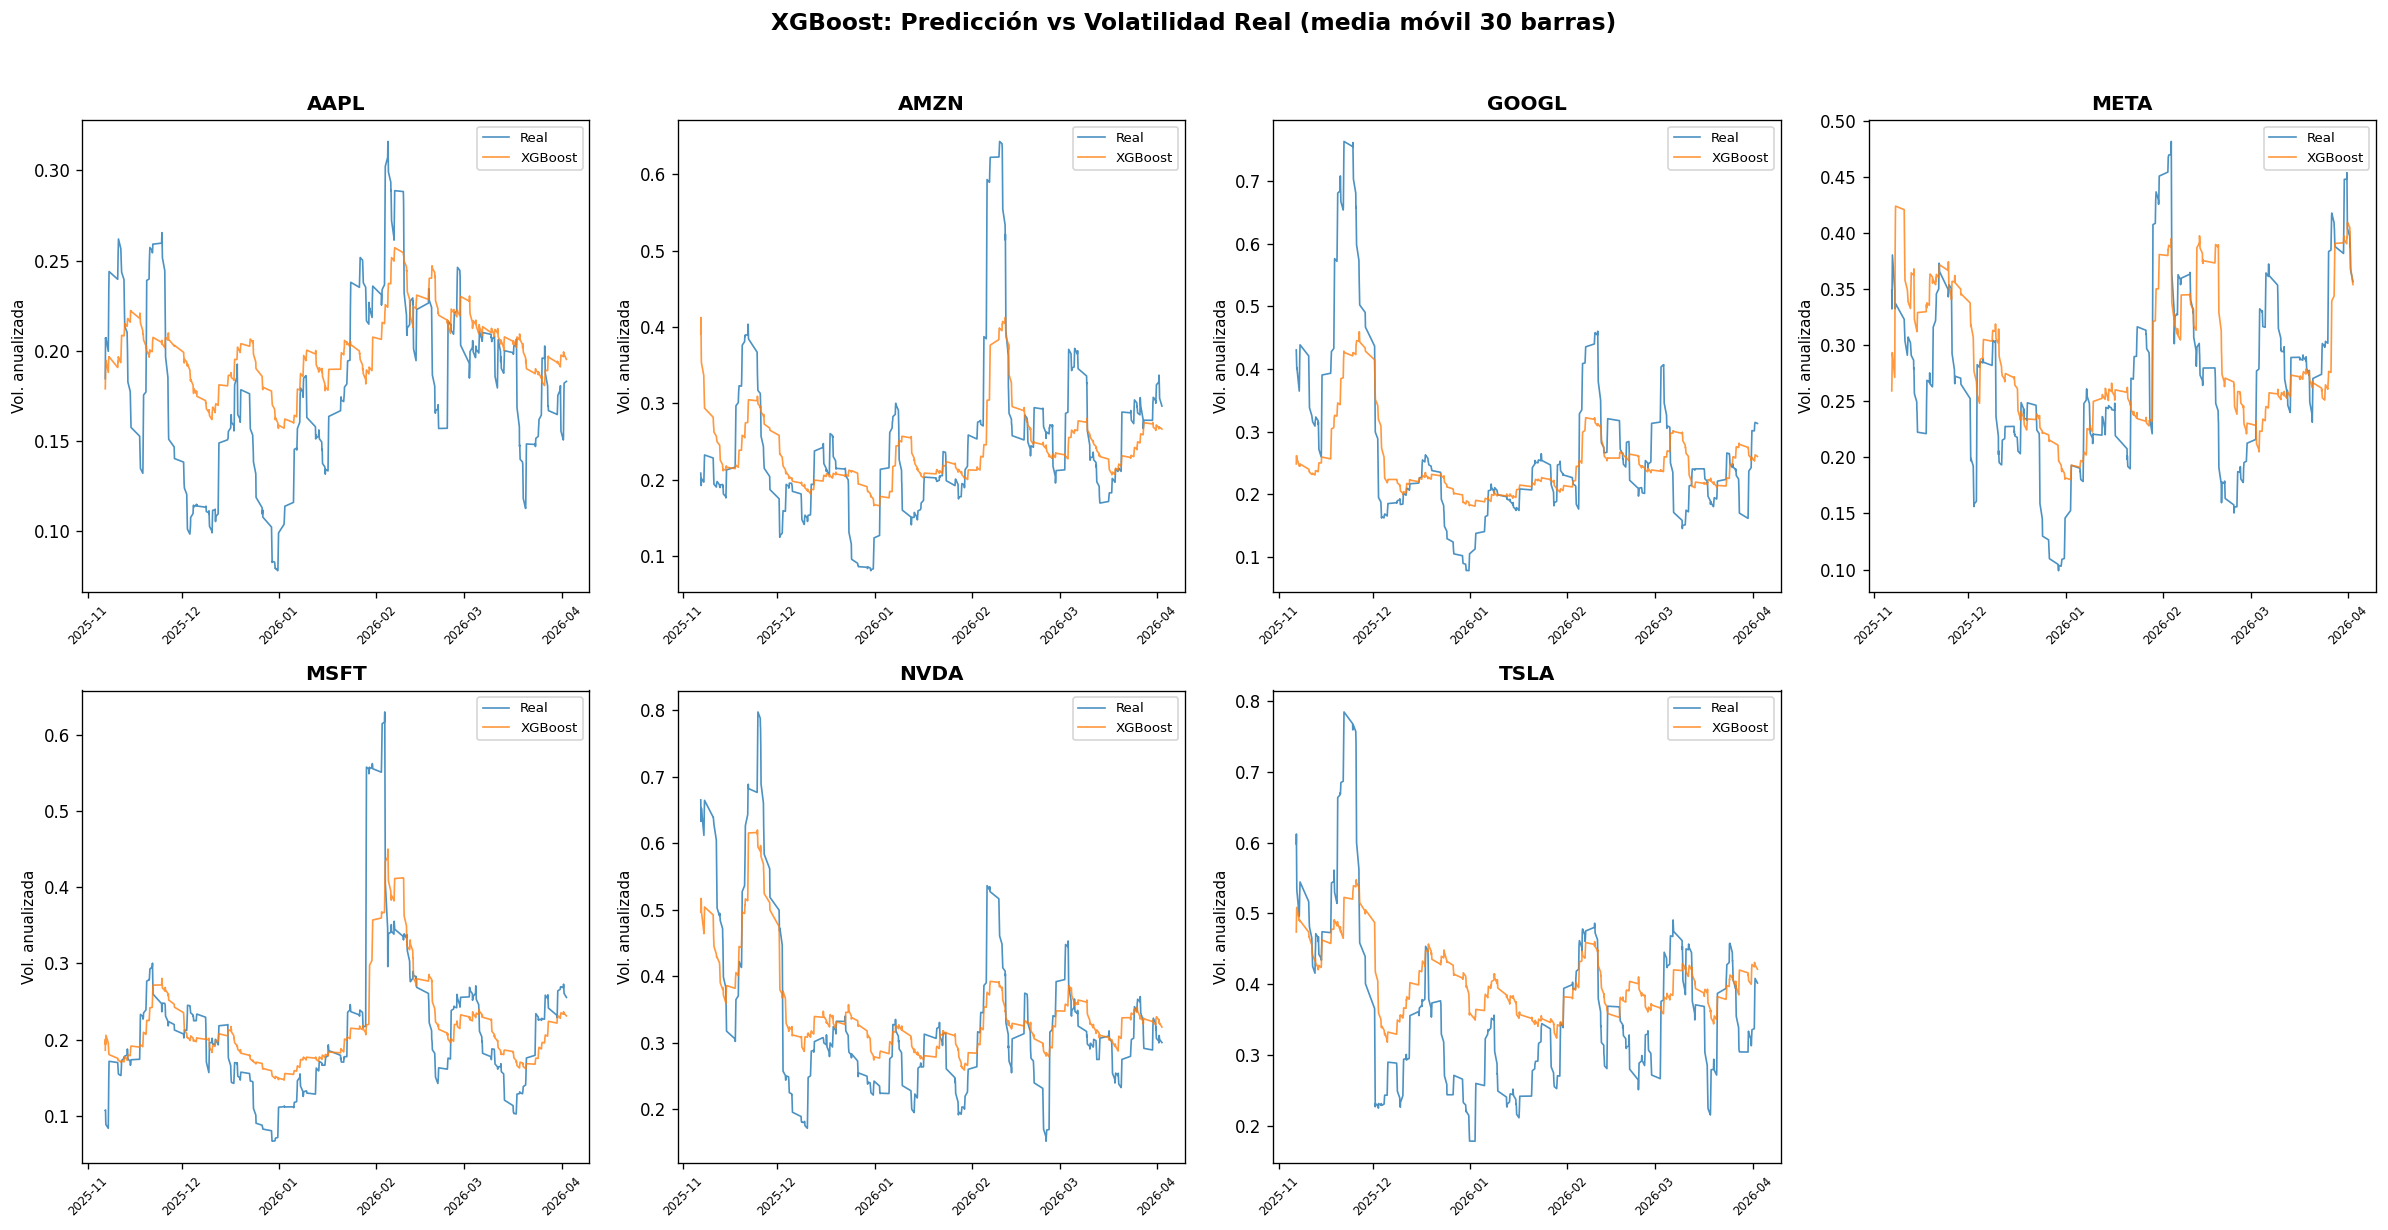

Guardada: /home/daniel-palacios/TFG-Magnificent7-Sentiment-Risk/docs/figuras/modelos_intraday_grid_XGBoost.png


In [17]:
# --- Figura 1: Grid XGBoost predicción vs real por ticker ---
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    pred_df = predicciones_xgb[ticker]
    
    # Media móvil de 30 barras para suavizar y mejorar legibilidad
    real_smooth = pred_df['real'].rolling(30, min_periods=1).mean()
    pred_smooth = pred_df['pred'].rolling(30, min_periods=1).mean()
    
    ax.plot(real_smooth.index, real_smooth, label='Real', alpha=0.8, linewidth=1)
    ax.plot(pred_smooth.index, pred_smooth, label='XGBoost', alpha=0.8, linewidth=1)
    ax.set_title(f'{ticker}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.set_ylabel('Vol. anualizada', fontsize=9)

# Ocultar subplot vacío
axes[7].axis('off')

fig.suptitle('XGBoost: Predicción vs Volatilidad Real (media móvil 30 barras)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(FIGURAS / 'modelos_intraday_grid_XGBoost.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardada: {FIGURAS / 'modelos_intraday_grid_XGBoost.png'}")

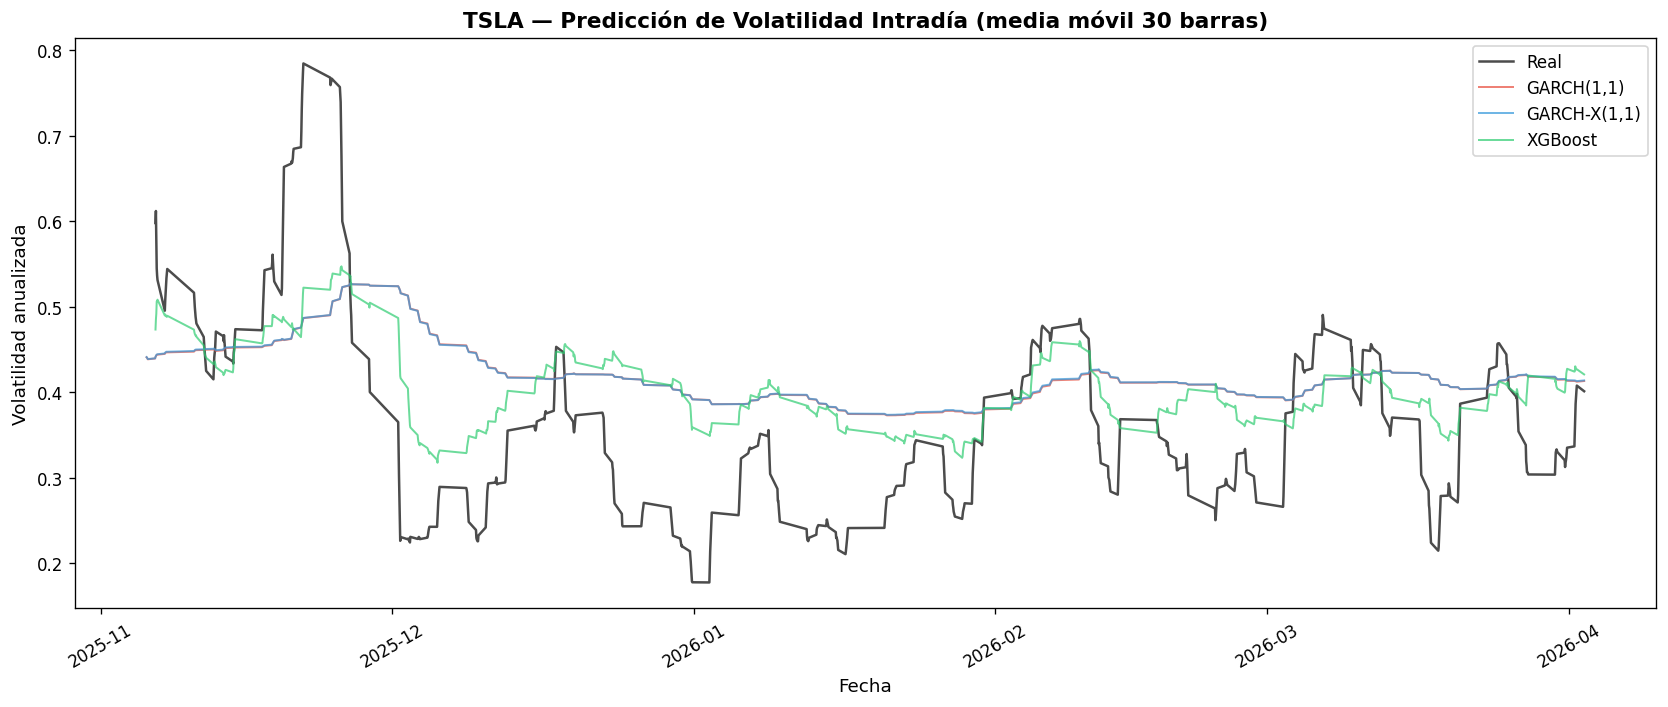

Guardada: /home/daniel-palacios/TFG-Magnificent7-Sentiment-Risk/docs/figuras/modelos_intraday_prediccion_TSLA.png


In [18]:
# --- Figura 2: TSLA — 3 modelos superpuestos ---
def plot_comparacion_ticker(ticker, filename):
    """Genera gráfico con 3 modelos superpuestos para un ticker."""
    fig, ax = plt.subplots(figsize=(14, 6))
    
    window = 30  # Media móvil para suavizar
    
    # Real (desde XGBoost que tiene más puntos)
    pred_xgb_t = predicciones_xgb[ticker]
    real_smooth = pred_xgb_t['real'].rolling(window, min_periods=1).mean()
    ax.plot(real_smooth.index, real_smooth, label='Real', color='black', alpha=0.7, linewidth=1.5)
    
    # GARCH
    if ticker in predicciones_garch:
        pred_g = predicciones_garch[ticker]
        g_smooth = pred_g['pred'].rolling(window, min_periods=1).mean()
        ax.plot(g_smooth.index, g_smooth, label='GARCH(1,1)', color='#e74c3c', alpha=0.7, linewidth=1.2)
    
    # GARCH-X
    if ticker in predicciones_garchx:
        pred_gx = predicciones_garchx[ticker]
        gx_smooth = pred_gx['pred'].rolling(window, min_periods=1).mean()
        ax.plot(gx_smooth.index, gx_smooth, label='GARCH-X(1,1)', color='#3498db', alpha=0.7, linewidth=1.2)
    
    # XGBoost
    xgb_smooth = pred_xgb_t['pred'].rolling(window, min_periods=1).mean()
    ax.plot(xgb_smooth.index, xgb_smooth, label='XGBoost', color='#2ecc71', alpha=0.7, linewidth=1.2)
    
    ax.set_title(f'{ticker} — Predicción de Volatilidad Intradía (media móvil {window} barras)', 
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Volatilidad anualizada')
    ax.legend(fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    fig.savefig(FIGURAS / filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Guardada: {FIGURAS / filename}")

plot_comparacion_ticker('TSLA', 'modelos_intraday_prediccion_TSLA.png')

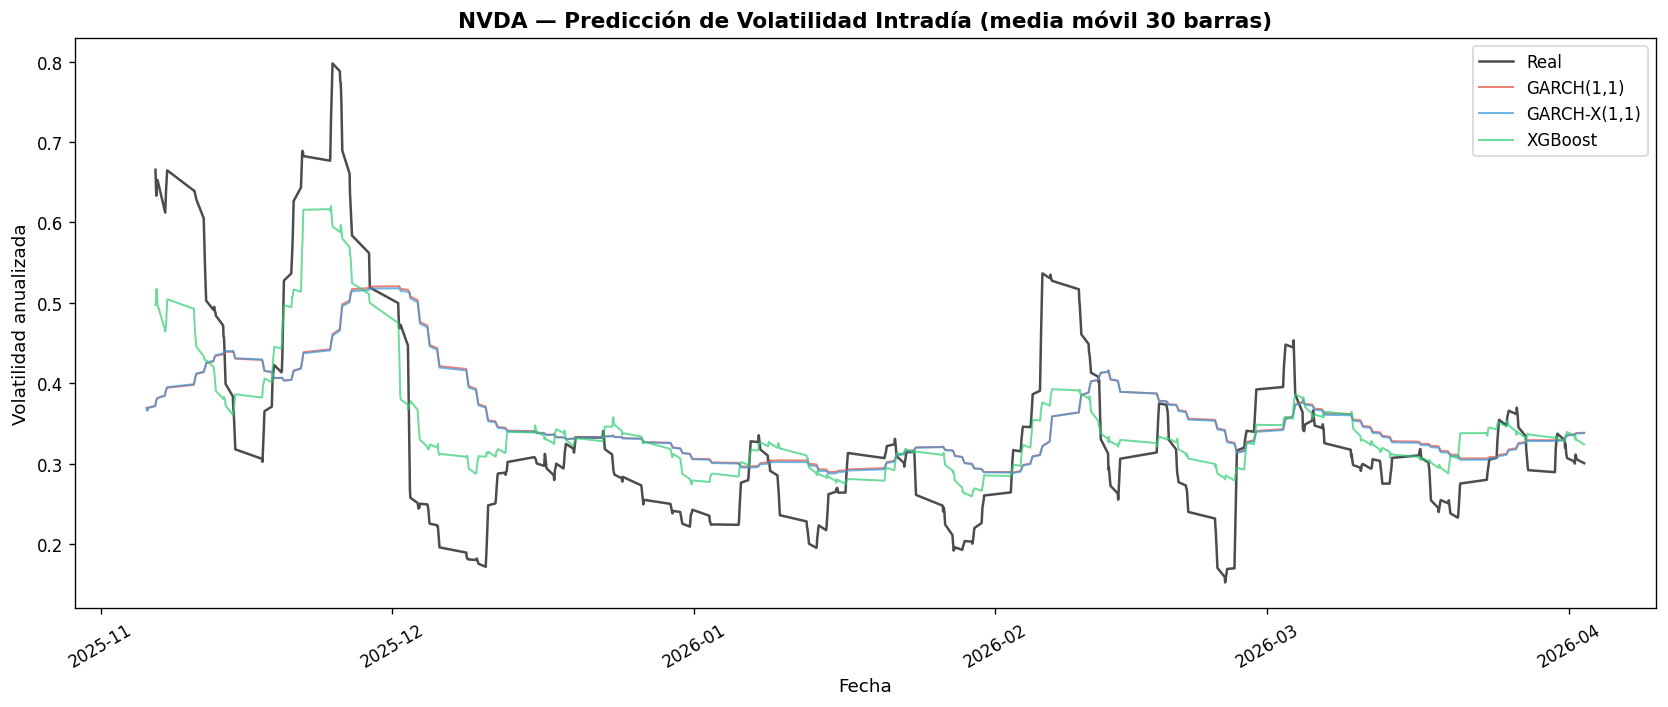

Guardada: /home/daniel-palacios/TFG-Magnificent7-Sentiment-Risk/docs/figuras/modelos_intraday_prediccion_NVDA.png


In [19]:
# --- Figura 3: NVDA — 3 modelos superpuestos ---
plot_comparacion_ticker('NVDA', 'modelos_intraday_prediccion_NVDA.png')

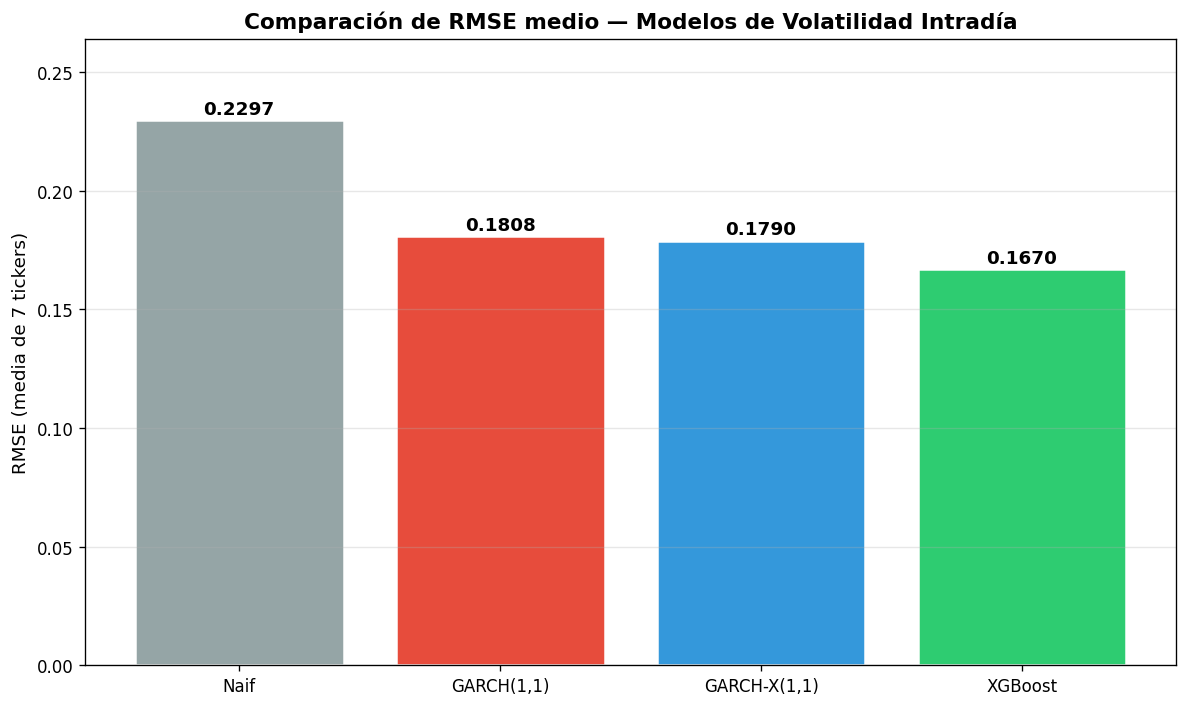

Guardada: /home/daniel-palacios/TFG-Magnificent7-Sentiment-Risk/docs/figuras/modelos_intraday_comparacion_rmse.png


In [20]:
# --- Figura 4: Comparación RMSE medio por modelo ---
fig, ax = plt.subplots(figsize=(10, 6))

modelos_nombres = ['Naif', 'GARCH(1,1)', 'GARCH-X(1,1)', 'XGBoost']
rmse_medios = [
    df_metricas_naif['rmse'].mean(),
    df_metricas_garch['rmse'].mean(),
    df_metricas_garchx['rmse'].mean(),
    df_metricas_xgb['rmse'].mean()
]

colores = ['#95a5a6', '#e74c3c', '#3498db', '#2ecc71']
bars = ax.bar(modelos_nombres, rmse_medios, color=colores, edgecolor='white', linewidth=1.5)

# Añadir valores sobre las barras
for bar, val in zip(bars, rmse_medios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Comparación de RMSE medio — Modelos de Volatilidad Intradía', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE (media de 7 tickers)')
ax.set_ylim(0, max(rmse_medios) * 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURAS / 'modelos_intraday_comparacion_rmse.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardada: {FIGURAS / 'modelos_intraday_comparacion_rmse.png'}")

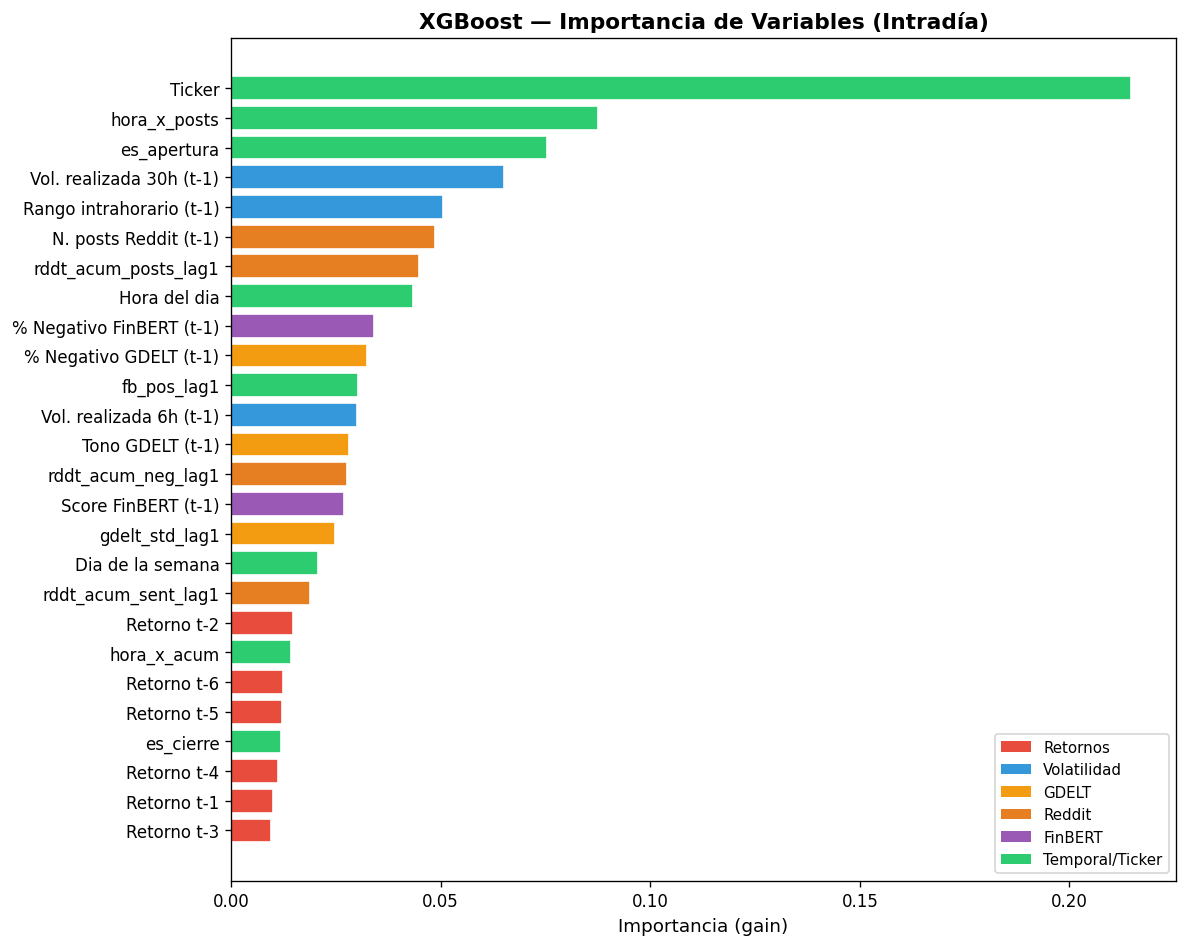

Guardada: /home/daniel-palacios/TFG-Magnificent7-Sentiment-Risk/docs/figuras/modelos_intraday_feature_importance.png


In [21]:
# --- Figura 5: Feature Importance de XGBoost ---
fig, ax = plt.subplots(figsize=(10, 8))

importancias = modelo_xgb.feature_importances_
indices = np.argsort(importancias)

# Nombres legibles para las features
nombres_legibles = {
    'ret_lag1': 'Retorno t-1', 'ret_lag2': 'Retorno t-2', 'ret_lag3': 'Retorno t-3',
    'ret_lag4': 'Retorno t-4', 'ret_lag5': 'Retorno t-5', 'ret_lag6': 'Retorno t-6',
    'vol6h_lag1': 'Vol. realizada 6h (t-1)', 'vol30h_lag1': 'Vol. realizada 30h (t-1)',
    'range_lag1': 'Rango intrahorario (t-1)',
    'tone_lag1': 'Tono GDELT (t-1)', 'gdelt_neg_lag1': '% Negativo GDELT (t-1)',
    'rddt_posts_lag1': 'N. posts Reddit (t-1)',
    'finbert_score_lag1': 'Score FinBERT (t-1)', 'finbert_neg_lag1': '% Negativo FinBERT (t-1)',
    'hora_enc': 'Hora del dia', 'dia_enc': 'Dia de la semana', 'ticker_enc': 'Ticker'
}

features_ordenadas = [FEATURES[i] for i in indices]
nombres_plot = [nombres_legibles.get(f, f) for f in features_ordenadas]
importancias_ordenadas = importancias[indices]

# Colores por tipo de variable
colores_feat = []
for f in features_ordenadas:
    if f.startswith('ret_'):
        colores_feat.append('#e74c3c')  # Retornos
    elif f.startswith('vol') or f.startswith('range'):
        colores_feat.append('#3498db')  # Volatilidad
    elif f.startswith('tone') or f.startswith('gdelt'):
        colores_feat.append('#f39c12')  # GDELT
    elif f.startswith('rddt'):
        colores_feat.append('#e67e22')  # Reddit
    elif f.startswith('finbert'):
        colores_feat.append('#9b59b6')  # FinBERT
    else:
        colores_feat.append('#2ecc71')  # Temporales

ax.barh(range(len(indices)), importancias_ordenadas, color=colores_feat, edgecolor='white')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels(nombres_plot, fontsize=10)
ax.set_xlabel('Importancia (gain)', fontsize=11)
ax.set_title('XGBoost — Importancia de Variables (Intradía)', fontsize=13, fontweight='bold')

# Leyenda manual
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor='#e74c3c', label='Retornos'),
    Patch(facecolor='#3498db', label='Volatilidad'),
    Patch(facecolor='#f39c12', label='GDELT'),
    Patch(facecolor='#e67e22', label='Reddit'),
    Patch(facecolor='#9b59b6', label='FinBERT'),
    Patch(facecolor='#2ecc71', label='Temporal/Ticker'),
]
ax.legend(handles=leyenda, loc='lower right', fontsize=9)

plt.tight_layout()
fig.savefig(FIGURAS / 'modelos_intraday_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardada: {FIGURAS / 'modelos_intraday_feature_importance.png'}")

## 8. Resumen final

Conclusiones principales del análisis de modelos de volatilidad intradía.

In [22]:
# --- Resumen final ---
print("=" * 90)
print("RESUMEN FINAL — MODELOS DE VOLATILIDAD INTRADÍA (Magnificent 7)")
print("=" * 90)

print(f"""
DATOS:
  - Periodo: 2024-04-03 → 2026-04-02
  - Frecuencia: Barras horarias (9:30-15:30 ET, 7 barras/día)
  - Variable objetivo: vol_fwd_6h (volatilidad realizada forward 6 barras)
  - Split temporal: {TRAIN_RATIO*100:.0f}% train / {(1-TRAIN_RATIO)*100:.0f}% test

MODELOS COMPARADOS:
  1. Naif (persistencia): vol_actual = vol_futura
  2. GARCH(1,1): Solo retornos horarios históricos
  3. GARCH-X(1,1): GARCH + tono GDELT + score FinBERT (retardados)
  4. XGBoost: Todas las variables (retornos + volatilidad + sentimiento + temporales)

RMSE MEDIO (7 tickers):
  - Naif:       {df_metricas_naif['rmse'].mean():.6f}
  - GARCH:      {df_metricas_garch['rmse'].mean():.6f}
  - GARCH-X:    {df_metricas_garchx['rmse'].mean():.6f}
  - XGBoost:    {df_metricas_xgb['rmse'].mean():.6f}

MAE MEDIO (7 tickers):
  - Naif:       {df_metricas_naif['mae'].mean():.6f}
  - GARCH:      {df_metricas_garch['mae'].mean():.6f}
  - GARCH-X:    {df_metricas_garchx['mae'].mean():.6f}
  - XGBoost:    {df_metricas_xgb['mae'].mean():.6f}
""")

# Identificar mejor modelo
rmse_medios_dict = {
    'Naif': df_metricas_naif['rmse'].mean(),
    'GARCH(1,1)': df_metricas_garch['rmse'].mean(),
    'GARCH-X(1,1)': df_metricas_garchx['rmse'].mean(),
    'XGBoost': df_metricas_xgb['rmse'].mean()
}
mejor = min(rmse_medios_dict, key=rmse_medios_dict.get)
print(f"MEJOR MODELO (menor RMSE medio): {mejor} ({rmse_medios_dict[mejor]:.6f})")

# Mejora del sentimiento
rmse_garch_mean = df_metricas_garch['rmse'].mean()
rmse_garchx_mean = df_metricas_garchx['rmse'].mean()
mejora_sent = (rmse_garch_mean - rmse_garchx_mean) / rmse_garch_mean * 100
print(f"\nMejora GARCH-X vs GARCH (efecto del sentimiento): {mejora_sent:+.2f}%")

rmse_xgb_mean = df_metricas_xgb['rmse'].mean()
mejora_xgb_naif = (df_metricas_naif['rmse'].mean() - rmse_xgb_mean) / df_metricas_naif['rmse'].mean() * 100
print(f"Mejora XGBoost vs Naif: {mejora_xgb_naif:+.2f}%")

print(f"""
FIGURAS GENERADAS:
  1. modelos_intraday_grid_XGBoost.png — Grid predicción vs real (7 tickers)
  2. modelos_intraday_prediccion_TSLA.png — TSLA: 3 modelos superpuestos
  3. modelos_intraday_prediccion_NVDA.png — NVDA: 3 modelos superpuestos
  4. modelos_intraday_comparacion_rmse.png — Barras RMSE medio por modelo
  5. modelos_intraday_feature_importance.png — Importancia de variables XGBoost
""")

RESUMEN FINAL — MODELOS DE VOLATILIDAD INTRADÍA (Magnificent 7)

DATOS:
  - Periodo: 2024-04-03 → 2026-04-02
  - Frecuencia: Barras horarias (9:30-15:30 ET, 7 barras/día)
  - Variable objetivo: vol_fwd_6h (volatilidad realizada forward 6 barras)
  - Split temporal: 80% train / 20% test

MODELOS COMPARADOS:
  1. Naif (persistencia): vol_actual = vol_futura
  2. GARCH(1,1): Solo retornos horarios históricos
  3. GARCH-X(1,1): GARCH + tono GDELT + score FinBERT (retardados)
  4. XGBoost: Todas las variables (retornos + volatilidad + sentimiento + temporales)

RMSE MEDIO (7 tickers):
  - Naif:       0.229712
  - GARCH:      0.180843
  - GARCH-X:    0.178985
  - XGBoost:    0.166961

MAE MEDIO (7 tickers):
  - Naif:       0.160804
  - GARCH:      0.127970
  - GARCH-X:    0.126713
  - XGBoost:    0.117870

MEJOR MODELO (menor RMSE medio): XGBoost (0.166961)

Mejora GARCH-X vs GARCH (efecto del sentimiento): +1.03%
Mejora XGBoost vs Naif: +27.32%

FIGURAS GENERADAS:
  1. modelos_intraday_grid